In [82]:
import pandas as pd
import numpy as np


In [ ]:
filepath = '../Datasets/MiningProcess_Flotation_Plant_Database.csv'

TIMESTAMP_COL = 'date'

# Seleccion de senales: solo se conservan las columnas cuyo nombre contiene
# SIGNAL_FILTER (None = todas). En el dataset ancho cada reactor lleva prefijo
# '<reactor>__' (ver pivot_reactors.py).
SIGNAL_FILTER = None   # dataset de flotacion: no hay prefijo por reactor

# Columnas a descartar por completo: las que contienen alguno de estos textos.
# ['Flotation Column'] = sin las 'Flotation Column NN Air Flow / Level';
# [] = con ellas (se exporta con sufijo '_flotcols', sin pisar la version sin ellas).
DROP_COLS_CONTAINING = []

# --- Opciones de preprocesado (activar/desactivar segun el analisis) ----------
# 1) Corte temporal: quedarse solo con un tramo del dataset.
#    Cualquiera de los dos limites puede ser None (= sin limite por ese lado).
APPLY_CUTOFF = False
DATASET_INIT_CUTOFF = pd.Timestamp('2017-03-29 12:00:00')   # inclusive
DATASET_END_CUTOFF = None                                   # inclusive

# 2) Reparto de timestamps duplicados: si el CSV guarda varias lecturas con el
#    mismo timestamp (p.ej. lecturas a 20 s sellados con la hora), se reparten
#    sumando k * TIMESTAMP_SPREAD_S segundos a la k-esima repeticion.
TIMESTAMP_SPREAD = True
TIMESTAMP_SPREAD_S = 20

# 3) Diezmado: quedarse con 1 de cada DECIMATION_FACTOR muestras (None = no).
#    Es un submuestreo sin filtro antialiasing: las oscilaciones mas rapidas que
#    la nueva frecuencia de Nyquist se "pliegan" sobre frecuencias bajas.
DECIMATION_FACTOR = None

# 4) Remuestreo: agregar a una rejilla temporal regular (None = no remuestrear).
#    Ejemplos: 'h' (horario), '10min', 'D'. RESAMPLE_AGG: 'mean', 'median', ...
RESAMPLE_RULE = 'h'                 # los laboratorios (% Silica/Iron) son horarios: se agrega a 1 h
RESAMPLE_AGG = 'mean'
# -----------------------------------------------------------------------------

# Este CSV usa coma decimal ('55,2'): sin decimal=',' los numeros se leerian como texto
df_raw = pd.read_csv(filepath, decimal=',')
df_raw[TIMESTAMP_COL] = pd.to_datetime(df_raw[TIMESTAMP_COL])

if SIGNAL_FILTER is not None:
    selected = [c for c in df_raw.columns if SIGNAL_FILTER in c]
    if not selected:
        raise ValueError(f'Ninguna columna contiene {SIGNAL_FILTER!r}')
    df_raw = df_raw[[TIMESTAMP_COL] + selected]
    print(f'Senales con {SIGNAL_FILTER!r}: {len(selected)}')

dropped_cols = [c for c in df_raw.columns if any(t in c for t in DROP_COLS_CONTAINING)]
df_raw = df_raw.drop(columns=dropped_cols)
print(f'Columnas descartadas ({len(dropped_cols)}):', dropped_cols)

# lab_cols = ['% Iron Feed', '% Silica Feed', '% Iron Concentrate', '% Silica Concentrate']
lab_cols = []

sensor_cols = [c for c in df_raw.columns if c not in [TIMESTAMP_COL] + lab_cols]

if TIMESTAMP_SPREAD:
    time_offsets = pd.to_timedelta(
        df_raw.groupby(TIMESTAMP_COL).cumcount() * TIMESTAMP_SPREAD_S, unit='s')
    df_raw.index = df_raw[TIMESTAMP_COL] + time_offsets
else:
    df_raw.index = df_raw[TIMESTAMP_COL]
df_raw = df_raw.drop(columns=TIMESTAMP_COL).sort_index()
df_raw.index.name = TIMESTAMP_COL
print(f'Cargado: {len(df_raw):,} filas  [{df_raw.index.min()} -> {df_raw.index.max()}]')

# El dataset original de flotacion tiene un hueco real de 13 dias y 7h: la ultima
# lectura antes del hueco es 2017-03-16 05:00 y la siguiente es 2017-03-29 12:00
# (no hay NaN en el CSV, simplemente no existen filas en ese intervalo). Con el
# corte se descarta lo anterior al hueco para quedarse con un tramo continuo.
if APPLY_CUTOFF:
    mask = pd.Series(True, index=df_raw.index)
    if DATASET_INIT_CUTOFF is not None:
        mask &= df_raw.index >= DATASET_INIT_CUTOFF
    if DATASET_END_CUTOFF is not None:
        mask &= df_raw.index <= DATASET_END_CUTOFF
    df_raw = df_raw[mask.values]
    print(f'Corte:    {len(df_raw):,} filas  [{df_raw.index.min()} -> {df_raw.index.max()}]')
    if df_raw.empty:
        raise ValueError('El corte deja el dataset vacio: revisa DATASET_INIT/END_CUTOFF')

if DECIMATION_FACTOR is not None and DECIMATION_FACTOR > 1:
    df_raw = df_raw.iloc[::DECIMATION_FACTOR]
    print(f'Diezmado x{DECIMATION_FACTOR}: {len(df_raw):,} filas')

# df: version agregada (si RESAMPLE_RULE) que se usa para todo el notebook salvo
# que se necesiten variaciones de alta frecuencia, en cuyo caso se usa df_raw.
# Solo se agregan columnas numericas: las categoricas no tienen media.
if RESAMPLE_RULE is not None:
    df = df_raw.select_dtypes('number').resample(RESAMPLE_RULE).agg(RESAMPLE_AGG)
    print(f'Remuestreo {RESAMPLE_RULE!r} ({RESAMPLE_AGG}): {len(df):,} filas')
else:
    df = df_raw.copy()


# Análisis inicial de señales

Antes de cualquier otro paso se revisa la variabilidad y los NaN de cada señal:

- **Constantes** (p. ej. setpoints fijos toda la campaña): se eliminan de `df_raw`
  y `df` (su valor queda en `constant_values`).
- **NaN estructural** (p. ej. `time_to_fault_min`, que solo existe antes de un
  fallo): se mantienen en los datos pero salen de `sensor_cols`.

In [84]:
# Analisis inicial de senales: variabilidad y NaN de cada columna de df_raw.
# - Constantes (un unico valor en todo el tramo, p.ej. setpoints fijos): no
#   aportan informacion y rompen transformaciones que dividen por la varianza
#   (Box-Cox, escalados, ...). Se guardan su valor y se ELIMINAN de df_raw y df.
# - NaN estructural (> STRUCTURAL_NAN_PCT % NaN, p.ej. time_to_fault_min, que
#   solo existe antes de un fallo): no son huecos de un sensor, sino una variable
#   definida a ratos. Se quedan en df_raw/df pero salen de sensor_cols.
STRUCTURAL_NAN_PCT = 50

numeric = df_raw.select_dtypes('number')
signal_screen = pd.DataFrame({
    'n_unicos': numeric.nunique(dropna=True),
    'std': numeric.std(),
    'cv_%': (numeric.std() / numeric.mean().abs() * 100),
    'pct_nan': numeric.isna().mean() * 100,
})
signal_screen['tipo'] = 'senal'
signal_screen.loc[signal_screen['pct_nan'] > STRUCTURAL_NAN_PCT, 'tipo'] = 'NaN estructural'
signal_screen.loc[signal_screen['n_unicos'] <= 1, 'tipo'] = 'constante'

constant_cols = signal_screen.index[signal_screen['tipo'] == 'constante'].tolist()
structural_nan_cols = signal_screen.index[signal_screen['tipo'] == 'NaN estructural'].tolist()
constant_values = {c: df_raw[c].dropna().iloc[0] for c in constant_cols}

df_raw = df_raw.drop(columns=constant_cols)
df = df.drop(columns=[c for c in constant_cols if c in df.columns])
sensor_cols = [c for c in sensor_cols if c not in constant_cols + structural_nan_cols]

display(signal_screen.round(4).sort_values('tipo'))
print('Eliminadas por constantes:', constant_values)
print('Fuera de sensor_cols (NaN estructural):', structural_nan_cols)
print(f'sensor_cols: {len(sensor_cols)} senales')

,n_unicos,std,cv_%,pct_nan,tipo
% Iron Feed,278,5.1577,9.1620,0.0,senal
% Silica Feed,293,6.8074,46.4617,0.0,senal
Starch Flow,409317,1215.2037,42.3543,0.0,senal
Amina Flow,319416,91.2305,18.6892,0.0,senal
Ore Pulp Flow,180189,9.6998,2.4397,0.0,senal
Ore Pulp pH,131143,0.3870,3.9621,0.0,senal
Ore Pulp Density,105805,0.0692,4.1210,0.0,senal
% Iron Concentrate,38696,1.1186,1.7197,0.0,senal
% Silica Concentrate,55569,1.1256,48.3742,0.0,senal


Eliminadas por constantes: {}
Fuera de sensor_cols (NaN estructural): []
sensor_cols: 9 senales


# Explorador interactivo de señales

Gráfico interactivo (Plotly) sobre `df` (agregado horario) para inspeccionar el
comportamiento de las señales a conveniencia:

- **Añadir/quitar señales**: click en su nombre en la leyenda (empiezan todas
  ocultas salvo las indicadas en `default_visible`).
- **Zoom**: arrastrar sobre la zona de interés; doble click para reset.
- **Navegar sin perder rango de zoom**: usar el range slider inferior.
- **Comparar valores en un instante**: el hover muestra todas las señales
  visibles en esa fecha (`hovermode='x unified'`).

Requiere `plotly` instalado en el entorno del kernel (`pip install plotly`).

In [85]:
import plotly.graph_objects as go

def plot_signals(data=df, columns=None, default_visible=None, height=650, title=None):
    """Grafico interactivo: una traza por columna, activable/desactivable desde
    la leyenda. `columns` por defecto es sensor_cols + lab_cols."""
    if columns is None:
        columns = sensor_cols + lab_cols
    if default_visible is None:
        default_visible = []

    fig = go.Figure()
    for col in columns:
        fig.add_trace(go.Scatter(
            x=data.index,
            y=data[col],
            name=col,
            mode='lines',
            line=dict(width=1.2),
            visible=True if col in default_visible else 'legendonly',
        ))

    fig.update_layout(
        height=height,
        title=title or 'Señales (click en la leyenda para mostrar/ocultar)',
        xaxis=dict(rangeslider=dict(visible=True), title='fecha'),
        yaxis=dict(title='valor'),
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0),
        hovermode='x unified',
        margin=dict(t=80),
    )
    return fig


# Ejemplo de uso: cambia `columns`/`default_visible` a conveniencia para cada analisis
plot_signals(df, default_visible=['% Silica Feed', '% Silica Concentrate']).show()

# Find missing values

In [86]:
# Conteo y % de NaN por columna (surgen del resample horario: una hora sin
# ninguna lectura original de 20s cae a NaN en el promedio)
nan_summary = pd.DataFrame({
    'n_nan': df.isna().sum(),
    'pct_nan': (df.isna().mean() * 100).round(2),
}).sort_values('n_nan', ascending=False)

print(f'Filas totales: {len(df)}')
nan_summary[nan_summary['n_nan'] > 0]


Filas totales: 4415


,n_nan,pct_nan
% Iron Feed,318,7.2
% Silica Feed,318,7.2
Starch Flow,318,7.2
Amina Flow,318,7.2
Ore Pulp Flow,318,7.2
Ore Pulp pH,318,7.2
Ore Pulp Density,318,7.2
% Iron Concentrate,318,7.2
% Silica Concentrate,318,7.2


In [87]:
# Patron temporal de los NaN: horas completamente vacias tras el resample
# (indican huecos de tiempo donde no habia ninguna lectura original en esa hora)
rows_all_nan = df[sensor_cols].isna().all(axis=1)
print(f'Filas totalmente NaN (huecos de tiempo): {rows_all_nan.sum()} de {len(df)}')

if rows_all_nan.any():
    gap_dates = df.index[rows_all_nan]
    print('Primeras fechas con hueco:', gap_dates[:10].tolist())


Filas totalmente NaN (huecos de tiempo): 318 de 4415
Primeras fechas con hueco: [Timestamp('2017-03-16 06:00:00'), Timestamp('2017-03-16 07:00:00'), Timestamp('2017-03-16 08:00:00'), Timestamp('2017-03-16 09:00:00'), Timestamp('2017-03-16 10:00:00'), Timestamp('2017-03-16 11:00:00'), Timestamp('2017-03-16 12:00:00'), Timestamp('2017-03-16 13:00:00'), Timestamp('2017-03-16 14:00:00'), Timestamp('2017-03-16 15:00:00')]


# Missing data handle

In [88]:
# Marca tramos donde % Silica Concentrate (y % Iron Concentrate) se queda en
# un valor ESTATICO durante mas de N dias seguidos. Posible artefacto de
# muestreo de laboratorio: los targets vienen de analisis manual, y si el
# laboratorio no analiza con la frecuencia que sugiere el timestamp (horario),
# el mismo valor se puede repetir/mantener varias lecturas seguidas sin que
# sea una dinamica real del proceso.
static_min_days = 1

def find_static_runs(series, min_days):
    """Devuelve un DataFrame con los tramos (inicio, fin, valor, duracion)
    donde `series` se mantiene EXACTAMENTE igual durante >= min_days."""
    s = series.dropna().sort_index()

    # id de racha: se incrementa cada vez que el valor cambia respecto al anterior
    run_id = (s != s.shift()).cumsum()

    runs = []
    for _, group in s.groupby(run_id):
        duration = group.index.max() - group.index.min()
        if duration >= pd.Timedelta(days=min_days):
            runs.append({
                'start': group.index.min(),
                'end': group.index.max(),
                'value': group.iloc[0],
                'duration_days': duration.total_seconds() / 86400,
                'n_readings': len(group),
            })

    return pd.DataFrame(runs).sort_values('duration_days', ascending=False) if runs else pd.DataFrame(
        columns=['start', 'end', 'value', 'duration_days', 'n_readings']
    )

# # Se incluye tambien % Silica Feed (input de laboratorio, no target): mismo
# # posible artefacto de muestreo, el valor se mantiene dias sin cambiar.
# static_targets = ['% Silica Concentrate', '% Iron Concentrate', '% Silica Feed']
# static_runs = {target: find_static_runs(df[target], static_min_days) for target in static_targets}

# for target, runs in static_runs.items():
#     total_days_static = runs['duration_days'].sum() if len(runs) else 0
#     print(f'{target}: {len(runs)} tramos estaticos >= {static_min_days} dias '
#           f'({total_days_static:.1f} dias en total)')

# display(static_runs['% Silica Concentrate'])
# static_runs['% Silica Feed']

In [89]:
# import matplotlib.pyplot as plt

# # Visualizacion: serie temporal completa (convencion del proyecto: siempre
# # los 60 dias/campaña completa antes de drill-down) con los tramos estaticos
# # resaltados como banda sombreada.
# fig, axes = plt.subplots(len(static_targets), 1, figsize=(14, 4.5 * len(static_targets)))
# if len(static_targets) == 1:
#     axes = [axes]

# for ax, target in zip(axes, static_targets):
#     series = df[target].dropna()
#     ax.plot(series.index, series.values, color='#4C72B0', linewidth=1, label=target)

#     runs = static_runs[target]
#     for i, row in runs.iterrows():
#         ax.axvspan(row['start'], row['end'], color='red', alpha=0.25,
#                    label=f'tramo estatico (>= {static_min_days}d)' if i == runs.index[0] else None)

#     ax.set_title(f'{target}: {len(runs)} tramos estaticos marcados')
#     ax.set_xlabel('fecha')a
#     ax.set_ylabel(target)
#     ax.legend(loc='upper right')
#     ax.grid(alpha=0.3)

# plt.tight_layout()
# plt.show()

# Mean imputation
## Peligroso! Coloca el promedio de todos los valores. Si hay cambio de regimen no funciona

In [90]:
import numpy as np
from sklearn.impute import SimpleImputer
mean_imputeModel = SimpleImputer(missing_values=np.nan, strategy='mean')
print(mean_imputeModel.fit_transform(df[sensor_cols]).shape)

(4415, 9)


# Hot-deck imputation

In [91]:
from sklearn.impute import KNNImputer
# KNNImputer compara cada fila con hueco contra todas las demas: coste ~n^2.
# Con df a 1 min (~130k filas) tarda ~10 min, asi que se ilustra sobre una
# ventana de KNN_DEMO_DAYS (la comparacion de metodos esta en la celda de
# visualizacion del relleno).
KNN_DEMO_DAYS = 3
knn_demo = df.loc[:df.index.min() + pd.Timedelta(days=KNN_DEMO_DAYS), sensor_cols]
knn_imputeModel = KNNImputer(n_neighbors=10)
print(knn_imputeModel.fit_transform(knn_demo).shape)


(73, 9)


# Kalman imputation (causal, con tendencia)

Filtro de Kalman con modelo de **nivel + pendiente** (*local linear trend*) que
recorre la serie solo hacia delante:

- Si hay medida: *predict* + *update* (corrige el estado con el valor medido).
- Si hay NaN: solo *predict* → el relleno es `nivel + pendiente` estimados con
  el pasado. No usa ningún valor posterior al hueco (a diferencia de la
  interpolación) y prolonga la tendencia reciente.

Parámetros: `r` (ruido de medida, se estima de los datos) y `q_level_ratio` /
`q_slope_ratio` (ruido de proceso relativo a `r`). Más alto → sigue antes a la
señal pero extrapola más la pendiente; tras un escalón brusco puede pasarse
unos minutos (sobreoscilación), porque la pendiente "aprendida" en el salto se
proyecta sobre el hueco.

In [92]:
# Filtro de Kalman "local linear trend" (nivel + pendiente), solo hacia delante.
#   estado x_t = [nivel, pendiente]
#   x_t = F x_{t-1} + w,  F = [[1, 1], [0, 1]],  w ~ N(0, diag(q_level, q_slope))
#   y_t = nivel_t + v,    v ~ N(0, r)
# Con medida: predict + update. Con NaN: solo predict -> el relleno es
# nivel + pendiente estimados con el pasado (causal) y la incertidumbre P crece
# mientras dura el hueco. El paso de tiempo es "una muestra": si se diezma o
# remuestrea, la pendiente pasa a ser por muestra de la nueva rejilla.
import numpy as np


def kalman_llt_fill(series, r=None, q_level_ratio=1e-2, q_slope_ratio=1e-4):
    """Rellena los NaN de `series` con la prediccion causal de un Kalman de
    nivel + tendencia. Devuelve (serie_rellena, nivel_filtrado).

    r: varianza del ruido de medida. Si es None se estima con los saltos entre
       muestras consecutivas: si domina el ruido blanco, var(diff) ~ 2r (se usa
       la MAD para que los escalones del proceso no la inflen).
    q_level_ratio, q_slope_ratio: ruido de proceso relativo a r. Mas alto =
       el filtro sigue mas rapido a la senal (y extrapola mas la pendiente);
       mas bajo = mas suave y mas lento ante cambios de nivel.
    """
    y = series.to_numpy(dtype=float)
    n = len(y)
    filled = y.copy()
    level = np.full(n, np.nan)

    observed = np.flatnonzero(~np.isnan(y))
    if len(observed) == 0:
        return pd.Series(filled, index=series.index), pd.Series(level, index=series.index)

    if r is None:
        d = np.diff(y)
        d = d[~np.isnan(d)]
        mad = np.median(np.abs(d - np.median(d))) * 1.4826 if len(d) else 0.0
        r = 0.5 * mad ** 2
    r = max(r, 1e-12)  # senales constantes (setpoints): evita dividir por cero
    q_l, q_s = q_level_ratio * r, q_slope_ratio * r

    # Arranque en la primera medida; antes de ella no hay pasado -> sigue NaN
    t0 = observed[0]
    x0, x1 = y[t0], 0.0
    p00, p01, p11 = r, 0.0, r
    level[t0] = x0

    for t in range(t0 + 1, n):
        # predict
        x0 = x0 + x1
        p00 = p00 + 2 * p01 + p11 + q_l
        p01 = p01 + p11
        p11 = p11 + q_s

        if np.isnan(y[t]):
            filled[t] = x0
        else:
            # update (H = [1, 0])
            s = p00 + r
            k0, k1 = p00 / s, p01 / s
            innov = y[t] - x0
            x0 += k0 * innov
            x1 += k1 * innov
            p11 = p11 - k1 * p01
            p01 = (1 - k0) * p01
            p00 = (1 - k0) * p00
        level[t] = x0

    return pd.Series(filled, index=series.index), pd.Series(level, index=series.index)

# KNN univariante causal

El `KNNImputer` multivariante busca vecinos usando **todas** las señales (la mayoría
sin relación con la que se rellena) y en **toda** la ventana (pasado y futuro).
Aquí cada señal se rellena solo con **su propio pasado**:

1. Patrón del hueco en *t*: los `lags` valores previos `[y(t-L), ..., y(t-1)]`.
2. Se buscan, en las últimas `lookback` muestras, los `k` instantes τ cuyo
   patrón previo más se parece.
3. Relleno = media de `y(τ)` en esos vecinos.

Es causal y no depende de otras señales. Los huecos consecutivos se rellenan
en orden, usando los rellenos previos como parte del patrón.

In [93]:
# KNN univariante y causal: cada senal se rellena solo con SU PROPIO PASADO.
# Para un hueco en t:
#   patron(t) = [y(t-L), ..., y(t-1)]           (los L valores previos)
#   candidatos = instantes tau en [t-W, t-1] con y(tau) observado
#   vecinos    = los k tau cuyo patron(tau) mas se parece a patron(t)
#   relleno    = media de y(tau) de esos vecinos ("que vino despues de
#                situaciones parecidas en el pasado reciente")
# Los huecos se recorren en orden y los ya rellenados entran en el patron de los
# siguientes, asi que los huecos de varias muestras seguidas tambien se rellenan.
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view


def knn_univariate_causal_fill(series, k=2, lags=1, lookback=1440):
    """Rellena los NaN de `series` con un KNN sobre ventanas de su propio pasado.

    k: numero de vecinos.
    lags: longitud L del patron (en muestras).
    lookback: W, cuantas muestras hacia atras se buscan vecinos (1440 = 24 h a 1 min).
        Acotarlo evita mezclar regimenes lejanos y mantiene el coste bajo.
    Devuelve la serie rellena; los NaN sin pasado suficiente se quedan como NaN.
    """
    y_obs = series.to_numpy(dtype=float)
    y = y_obs.copy()                         # se va rellenando en orden
    # patterns[i] = y[i : i+lags] = patron previo al instante i+lags (vista, ve los rellenos)
    patterns = sliding_window_view(y, lags)

    for t in np.flatnonzero(np.isnan(y_obs)):
        if t < lags:
            continue
        query = y[t - lags:t]
        if np.isnan(query).any():            # sin pasado completo (inicio de la serie)
            continue

        tau = np.arange(max(lags, t - lookback), t)
        tau = tau[~np.isnan(y_obs[tau])]     # el vecino debe tener valor REAL en tau
        if len(tau) == 0:
            continue
        cand = patterns[tau - lags]
        ok = ~np.isnan(cand).any(axis=1)
        tau, cand = tau[ok], cand[ok]
        if len(tau) == 0:
            continue

        dist = np.sqrt(((cand - query) ** 2).sum(axis=1))
        nn = tau[np.argsort(dist)[:k]]
        y[t] = y_obs[nn].mean()

    return pd.Series(y, index=series.index)

# Visualización del relleno de valores vacíos

Compara, sobre la señal original a 1 min (`df_raw`), los valores que pone cada
método de imputación en los huecos (NaN, banda gris): interpolación temporal,
media global, KNN multivariante,
Kalman y KNN univariante. Con `PLOT_METHODS` se eligen los métodos a dibujar. Ajusta la ventana con `PLOT_START` / `PLOT_HOURS` y las
señales con `PLOT_COLS`.

In [94]:
# Relleno de NaN frente a la senal original. Se trabaja sobre df_raw (1 min):
# en df (media horaria) casi no quedan NaN, porque la media de cada hora ya
# ignora los minutos vacios y "rellena" sin que se vea.
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer, SimpleImputer

IMPUTE_START = df_raw.index.min()   # inicio de la ventana de imputacion
IMPUTE_DAYS = 3                     # KNN escala ~n^2: 3 dias ~1 s, 7 dias ~4 s, todo ~10 min
PLOT_START = IMPUTE_START + pd.Timedelta(hours=12)
PLOT_HOURS = 6                      # a 1 min/muestra, mas de unas horas no deja ver los puntos
PLOT_COLS = None                    # None = todas las imputadas; o lista de columnas
PLOT_METHODS = None                 # None = todos; o lista, p.ej. ['Kalman (causal)', 'KNN univariante (causal)']
MAX_NAN_PCT = 50                    # por encima no se imputa (NaN estructural, no huecos)

nan_pct = df_raw.isna().mean() * 100
numeric_cols = df_raw.select_dtypes('number').columns
impute_cols = [c for c in numeric_cols if 0 < nan_pct[c] <= MAX_NAN_PCT]
print('Sin NaN (nada que rellenar):', [c for c in numeric_cols if nan_pct[c] == 0])
print(f'No se imputan (> {MAX_NAN_PCT}% NaN):', [c for c in numeric_cols if nan_pct[c] > MAX_NAN_PCT])

if not impute_cols:
    print('No hay NaN en ninguna senal: no hay nada que rellenar/visualizar.')
else:
    window_end = IMPUTE_START + pd.Timedelta(days=IMPUTE_DAYS)
    window = df_raw.loc[IMPUTE_START:window_end, impute_cols]
    missing_mask = window.isna()


    def as_frame(values):
        return pd.DataFrame(values, index=window.index, columns=impute_cols)


    # - interpolacion: se calcula sobre la serie completa (barato) y se recorta.
    # - media: media GLOBAL de todo df_raw, no de la ventana (es lo que haria el
    #   imputador ajustado sobre el dataset entero).
    # - KNN (multivariante): solo ve las filas de la ventana (por coste); los vecinos
    #   son instantes con valores parecidos en las OTRAS senales, de cualquier
    #   momento de la ventana (pasado O futuro) -> NO causal.
    # - interpolacion NO es causal (usa el valor siguiente al hueco); Kalman si.
    imputed = {
        'interpolacion temporal': df_raw[impute_cols]
            .interpolate(method='time', limit_area='inside').loc[window.index],
        'media global': as_frame(
            SimpleImputer(strategy='mean').fit(df_raw[impute_cols]).transform(window)),
        'KNN multivariante (no causal)': as_frame(KNNImputer(n_neighbors=10).fit_transform(window)),
        # Kalman: causal, se pasa por la serie completa (sin transitorio de arranque
        # al inicio de la ventana) y se recorta. Ver kalman_llt_fill() arriba.
        'Kalman (causal)': pd.DataFrame(
            {c: kalman_llt_fill(df_raw[c])[0] for c in impute_cols}).loc[window.index],
        # KNN univariante: causal, solo el pasado de cada senal. Se le dan las
        # 1440 muestras (24 h, su lookback) previas a la ventana para que el inicio tenga vecinos.
        'KNN univariante (causal)': pd.DataFrame(
            {c: knn_univariate_causal_fill(df_raw.loc[:window_end, c].iloc[-(len(window) + 1440):])
             for c in impute_cols}).loc[window.index],
    }

    print(f'\nVentana {window.index.min()} -> {window.index.max()}: '
          f'{missing_mask.values.sum():,} valores rellenados en {len(impute_cols)} columnas')

    # Original en gris neutro (contexto); cada metodo con su color y forma de marcador
    method_style = {
        'interpolacion temporal': dict(color='#2a78d6', marker='o'),
        'media global': dict(color='#eb6834', marker='s'),
        'KNN multivariante (no causal)': dict(color='#1baf7a', marker='^'),
        'Kalman (causal)': dict(color='#eda100', marker='D'),
        'KNN univariante (causal)': dict(color='#e87ba4', marker='v'),
    }
    if PLOT_METHODS is not None:
        method_style = {m: s for m, s in method_style.items() if m in PLOT_METHODS}

    plot_cols = PLOT_COLS or impute_cols
    plot_slice = slice(PLOT_START, PLOT_START + pd.Timedelta(hours=PLOT_HOURS))
    half_step = (window.index[1] - window.index[0]) / 2

    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(14, 2.6 * len(plot_cols)),
                             sharex=True, squeeze=False)
    for ax, col in zip(axes[:, 0], plot_cols):
        original = window.loc[plot_slice, col]
        gaps = missing_mask.loc[plot_slice, col]

        for i, t in enumerate(gaps.index[gaps]):
            ax.axvspan(t - half_step, t + half_step, color='#d9d9d9', lw=0, zorder=0,
                       label='hueco (NaN)' if i == 0 else None)
        ax.plot(original.index, original.values, color='#555555', lw=1.2,
                label='original')
        for name, style in method_style.items():
            filled = imputed[name].loc[plot_slice, col][gaps]
            ax.scatter(filled.index, filled.values, s=45, edgecolors='white',
                       linewidths=1, zorder=3, label=name, **style)

        ax.set_ylabel(col.split('__', 1)[-1], fontsize=9)
        ax.set_title(f'{col}: {int(gaps.sum())} huecos en el tramo', fontsize=9, loc='left')
        ax.grid(alpha=0.3)

    # Leyenda unica: se recogen de todos los paneles (alguno puede no tener huecos)
    legend = {}
    for ax in axes[:, 0]:
        for h, l in zip(*ax.get_legend_handles_labels()):
            legend.setdefault(l, h)
    fig.legend(legend.values(), legend.keys(), loc='upper center', ncol=len(legend),
               bbox_to_anchor=(0.5, 1.0))
    fig.suptitle(f'Relleno de NaN vs senal original ({PLOT_HOURS} h desde {PLOT_START})', y=1.02)
    axes[-1, 0].set_xlabel('fecha')
    plt.tight_layout(rect=(0, 0, 1, 0.98))
    plt.show()

Sin NaN (nada que rellenar): ['% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow', 'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density', '% Iron Concentrate', '% Silica Concentrate']
No se imputan (> 50% NaN): []
No hay NaN en ninguna senal: no hay nada que rellenar/visualizar.


# Aplicar relleno: KNN univariante (causal)

Se rellena `df_raw` completo con el método elegido y se recalcula `df` con el
mismo remuestreo de la carga, de modo que el resto del notebook (histogramas,
skewness, ...) trabaja con los datos rellenados.

- `df_raw_unfilled`: copia de `df_raw` antes del relleno.
- `filled_mask`: `True` donde el valor es un relleno y no una medida real.

In [95]:
# Aplicar el relleno elegido: KNN univariante (causal) sobre df_raw COMPLETO.
# - df_raw_unfilled: copia del estado previo (para poder comparar / deshacer).
# - filled_mask: True donde el valor de df_raw es un relleno, no una medida.
# - df se recalcula desde df_raw rellenado con el mismo remuestreo de la carga,
#   asi todo lo que viene despues (histogramas, skewness, ...) usa los rellenos.
import time

FILL_K = 10
FILL_LAGS = 5
FILL_LOOKBACK = 1440    # muestras hacia atras para buscar vecinos (24 h a 1 min)
FILL_MAX_NAN_PCT = 50   # por encima no se rellena (NaN estructural, p.ej. time_to_fault_min)

# Re-ejecucion de esta celda: df_raw lleva la marca attrs['filled'] tras el
# relleno; si ya esta rellenado se parte de nuevo de la copia sin rellenar.
# (Al re-ejecutar la celda de carga, df_raw es nuevo y no lleva la marca.)
if df_raw.attrs.get('filled'):
    df_raw = df_raw_unfilled.copy()

nan_pct = df_raw.isna().mean() * 100
fill_cols = [c for c in df_raw.select_dtypes('number').columns
             if 0 < nan_pct[c] <= FILL_MAX_NAN_PCT]

df_raw_unfilled = df_raw.copy()
df_raw_unfilled.attrs.pop('filled', None)   # copy() hereda attrs
filled_mask = df_raw[fill_cols].isna()

t0 = time.time()
for c in fill_cols:
    df_raw[c] = knn_univariate_causal_fill(
        df_raw[c], k=FILL_K, lags=FILL_LAGS, lookback=FILL_LOOKBACK)
print(f'Relleno KNN univariante: {int(filled_mask.values.sum()):,} valores en '
      f'{len(fill_cols)} columnas ({time.time() - t0:.0f} s)')

# Lo que no se ha podido rellenar: NaN al inicio de la serie, sin `lags` valores
# previos. Son pocos y en el arranque; se dejan como NaN en vez de inventarlos.
still_nan = df_raw[fill_cols].isna().sum()
print('NaN que quedan (sin pasado suficiente):', still_nan[still_nan > 0].to_dict() or 'ninguno')
print('Sin huecos (nada que rellenar):',
      [c for c in df_raw.columns if c not in fill_cols and nan_pct[c] == 0])
print(f'No se rellenan (> {FILL_MAX_NAN_PCT}% NaN, estructural):',
      [c for c in df_raw.columns if nan_pct[c] > FILL_MAX_NAN_PCT])
df_raw.attrs['filled'] = True

if RESAMPLE_RULE is not None:
    df = df_raw.select_dtypes('number').resample(RESAMPLE_RULE).agg(RESAMPLE_AGG)
    print(f'df recalculado: remuestreo {RESAMPLE_RULE!r} ({RESAMPLE_AGG}), {len(df):,} filas')
else:
    df = df_raw.copy()
    print(f'df recalculado: sin remuestreo, {len(df):,} filas')

Relleno KNN univariante: 0 valores en 0 columnas (0 s)
NaN que quedan (sin pasado suficiente): ninguno
Sin huecos (nada que rellenar): ['% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow', 'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density', '% Iron Concentrate', '% Silica Concentrate']
No se rellenan (> 50% NaN, estructural): []
df recalculado: remuestreo 'h' (mean), 4,415 filas


# Histogram analysis

Excluidas por constantes: []


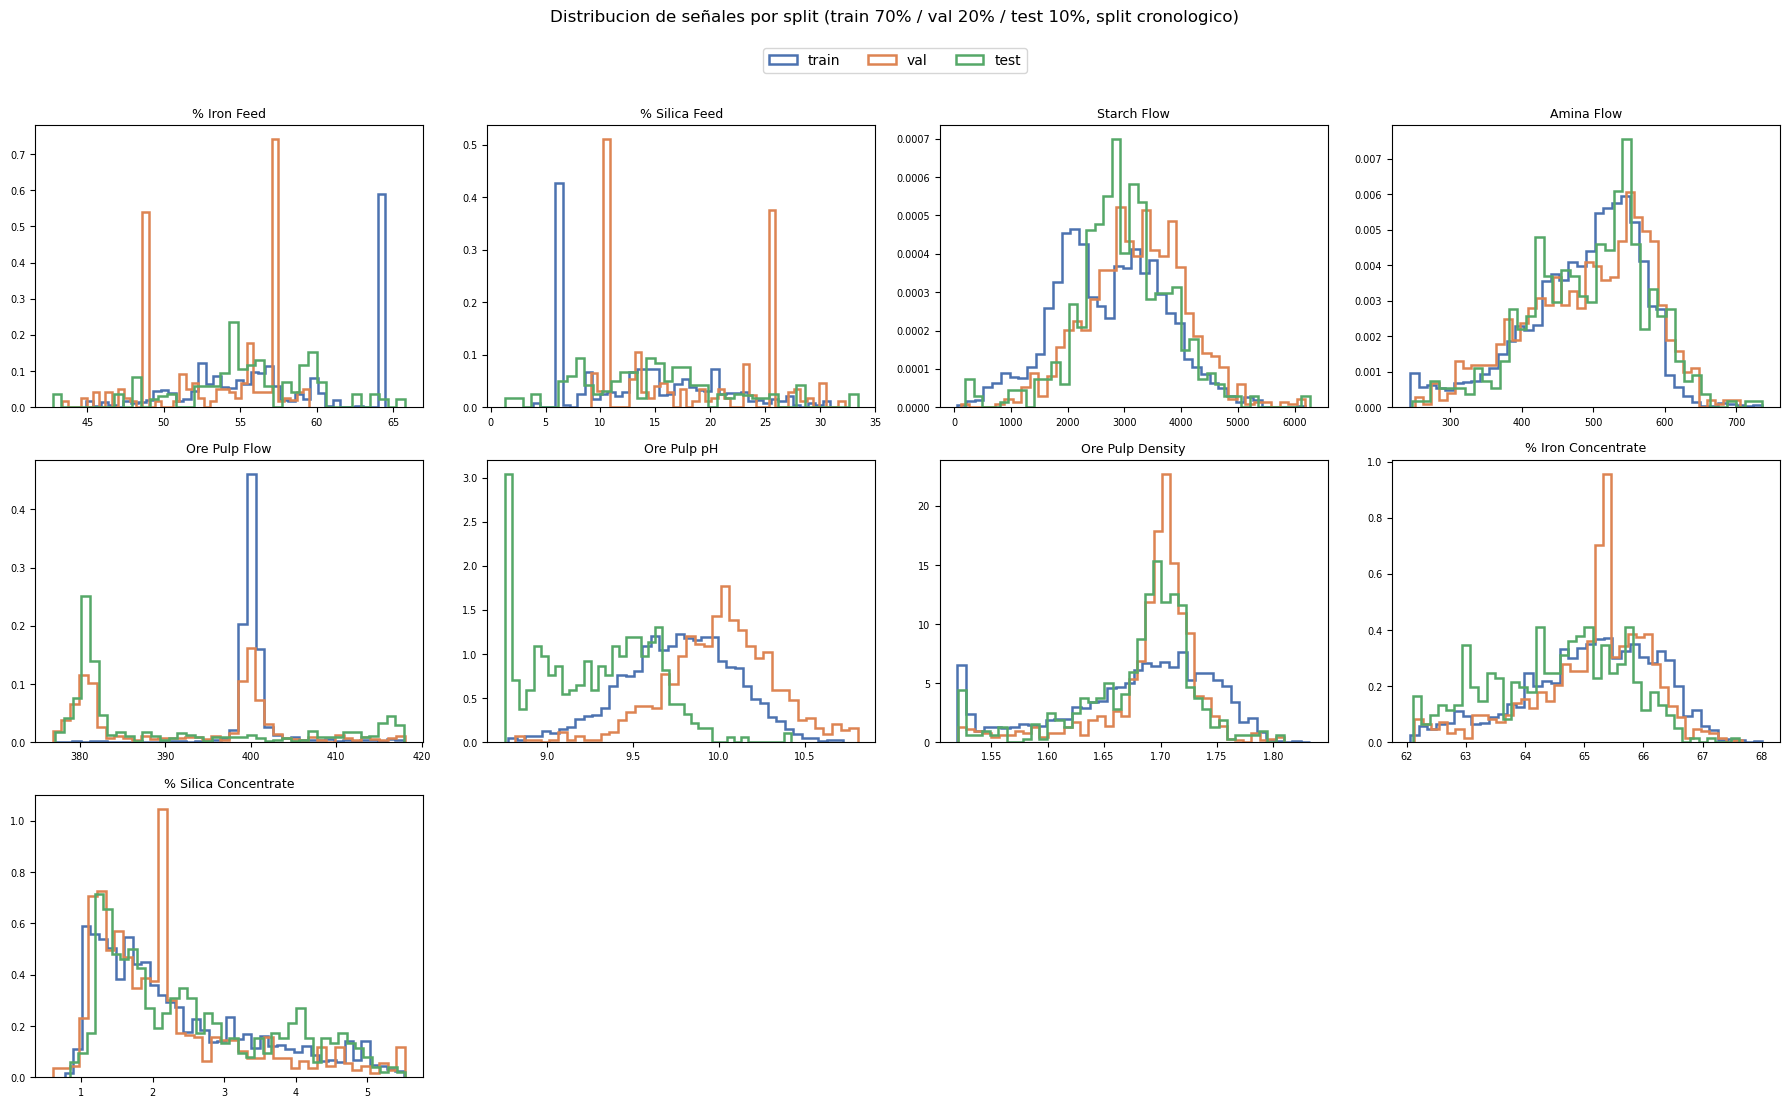

In [96]:
import matplotlib.pyplot as plt

# Split cronologico 70/20/10 (train/val/test) - nunca aleatorio en series temporales
n = len(df)
n_train = int(n * 0.7)
n_val = int(n * 0.9)

split_labels = pd.Series('test', index=df.index)
split_labels.iloc[:n_train] = 'train'
split_labels.iloc[n_train:n_val] = 'val'

split_colors = {'train': '#4C72B0', 'val': '#DD8452', 'test': '#55A868'}
# Las columnas constantes (p.ej. setpoints fijos toda la campana) no tienen
# distribucion: el histograma es una barra y Box-Cox falla ('Data must not be
# constant'). Se excluyen aqui y, con ellas, de las celdas de skewness.
constant_cols = [c for c in sensor_cols + lab_cols if df[c].nunique(dropna=True) <= 1]
hist_cols = [c for c in sensor_cols + lab_cols if c not in constant_cols]
print('Excluidas por constantes:', constant_cols)

n_cols = 4
n_rows = int(np.ceil(len(hist_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, hist_cols):
    for split_name, color in split_colors.items():
        values = df.loc[split_labels == split_name, col].dropna()
        ax.hist(values, bins=40, color=color, label=split_name, density=True,
                histtype='step', linewidth=1.8)
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)

for ax in axes[len(hist_cols):]:
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.02), fontsize=10)
fig.suptitle('Distribucion de señales por split (train 70% / val 20% / test 10%, split cronologico)', y=1.05)
plt.tight_layout()
plt.show()

In [97]:
# Skewness por señal (mismas columnas que el histograma de arriba)
# skew > 0: cola larga a la derecha | skew < 0: cola larga a la izquierda
# |skew| < 0.5: aprox simetrica | 0.5-1: moderada | > 1: fuerte
from scipy.stats import skew

skew_summary = pd.DataFrame({
    'skewness': {col: skew(df[col].dropna()) for col in hist_cols},
})
skew_summary['abs_skewness'] = skew_summary['skewness'].abs()
skew_summary = skew_summary.sort_values('abs_skewness', ascending=False)

skew_summary

,skewness,abs_skewness
% Silica Concentrate,0.967099,0.967099
Ore Pulp Density,-0.915401,0.915401
Ore Pulp Flow,-0.852465,0.852465
Amina Flow,-0.614230,0.614230
% Iron Concentrate,-0.519293,0.519293
% Silica Feed,0.439705,0.439705
Ore Pulp pH,-0.364480,0.364480
Starch Flow,-0.030150,0.030150
% Iron Feed,0.000420,0.000420


### Transformaciones para tratar el skewness: ventajas e inconvenientes

| Método | Ventajas | Inconvenientes |
|---|---|---|
| **Log** | Muy eficaz con skew positivo fuerte y colas largas; fácil de interpretar (efectos multiplicativos); sin parámetros que ajustar. | Solo definido para x > 0 (hay que desplazar los datos); puede **sobrecorregir** skew moderado y dejar cola en el lado contrario; para skew negativo hay que reflejar antes (invierte el orden); el desplazamiento elegido afecta al resultado. |
| **Raíz cuadrada** | Más suave que el log, ideal para skew moderado; admite x = 0; sin parámetros. | Menos potente con skew fuerte; requiere x ≥ 0 (desplazar/reflejar si no); la escala transformada es menos interpretable. |
| **Box-Cox** | Busca automáticamente el λ óptimo (incluye log y raíz como casos particulares); suele dar la distribución más cercana a la normal. | Exige x > 0 estricto (desplazar); λ estimado con los datos → **hay que ajustarlo solo con train** para evitar fuga de información; sensible a outliers; resultado poco interpretable. |
| **Yeo-Johnson** | Igual de flexible que Box-Cox pero acepta ceros y negativos sin desplazar; trata skew positivo y negativo. | Mismo riesgo de fuga (ajustar λ solo en train); sensible a outliers; menos interpretable; con distribuciones multimodales no las «arregla». |

**Notas generales**
- Ninguna transformación soluciona distribuciones bimodales; solo reducen la asimetría.
- Ajustar λ y desplazamientos solo con el conjunto de entrenamiento (en series temporales, días 1–45) y reutilizarlos en test.
- `df` no se ha modificado: las versiones transformadas están en `transformed[columna][método]`.
- Las variables con skew negativo (p. ej. *Air Flow*) se reflejan para Log/Sqrt/Box-Cox, por lo que su orden queda invertido.


,reflejada,Original,Log,Sqrt,Box-Cox,Yeo-Johnson,lambda_BoxCox,lambda_YeoJohnson,mejor_metodo
columna,,,,,,,,,
% Iron Feed,False,0.000,-1.354,-0.484,-0.080,-0.033,0.901,0.973,Yeo-Johnson
% Silica Feed,False,0.440,-0.423,0.056,-0.056,0.071,0.366,0.636,Box-Cox
Starch Flow,True,-0.030,-4.643,-0.590,-0.004,0.016,0.963,1.026,Box-Cox
Amina Flow,True,-0.614,-2.047,0.057,0.065,0.023,0.505,1.384,Yeo-Johnson
Ore Pulp Flow,True,-0.852,-2.178,-0.226,0.173,0.395,0.646,1.476,Box-Cox
Ore Pulp pH,True,-0.364,-0.210,0.087,0.002,0.013,0.352,1.207,Box-Cox
Ore Pulp Density,True,-0.915,0.791,0.854,0.035,0.030,-5.718,1.613,Yeo-Johnson
% Iron Concentrate,True,-0.519,-0.199,0.184,-0.005,-0.002,0.243,1.349,Yeo-Johnson
% Silica Concentrate,False,0.967,0.396,0.684,0.072,0.156,-0.560,0.132,Box-Cox


Skewness absoluto medio por metodo:
Original       0.523
Log            1.360
Sqrt           0.358
Box-Cox        0.055
Yeo-Johnson    0.082
dtype: float64


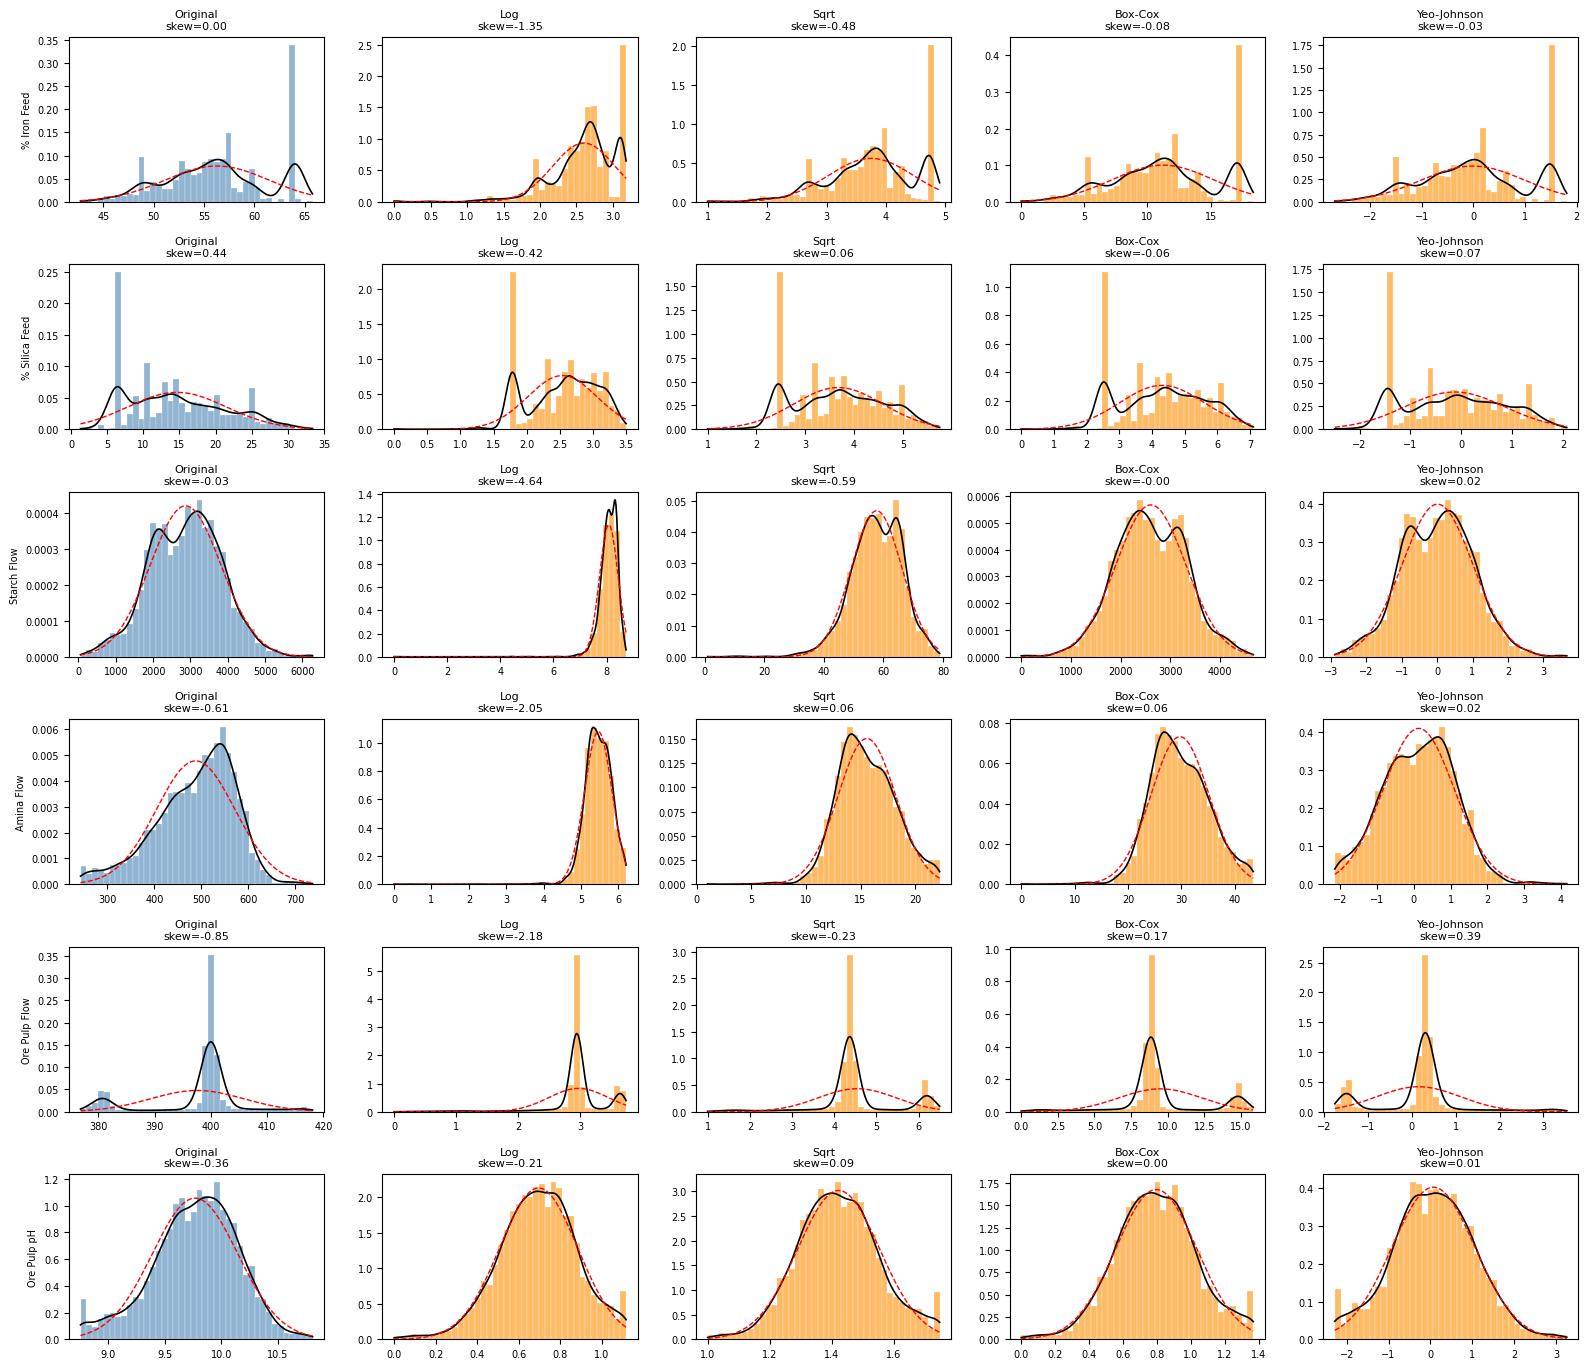

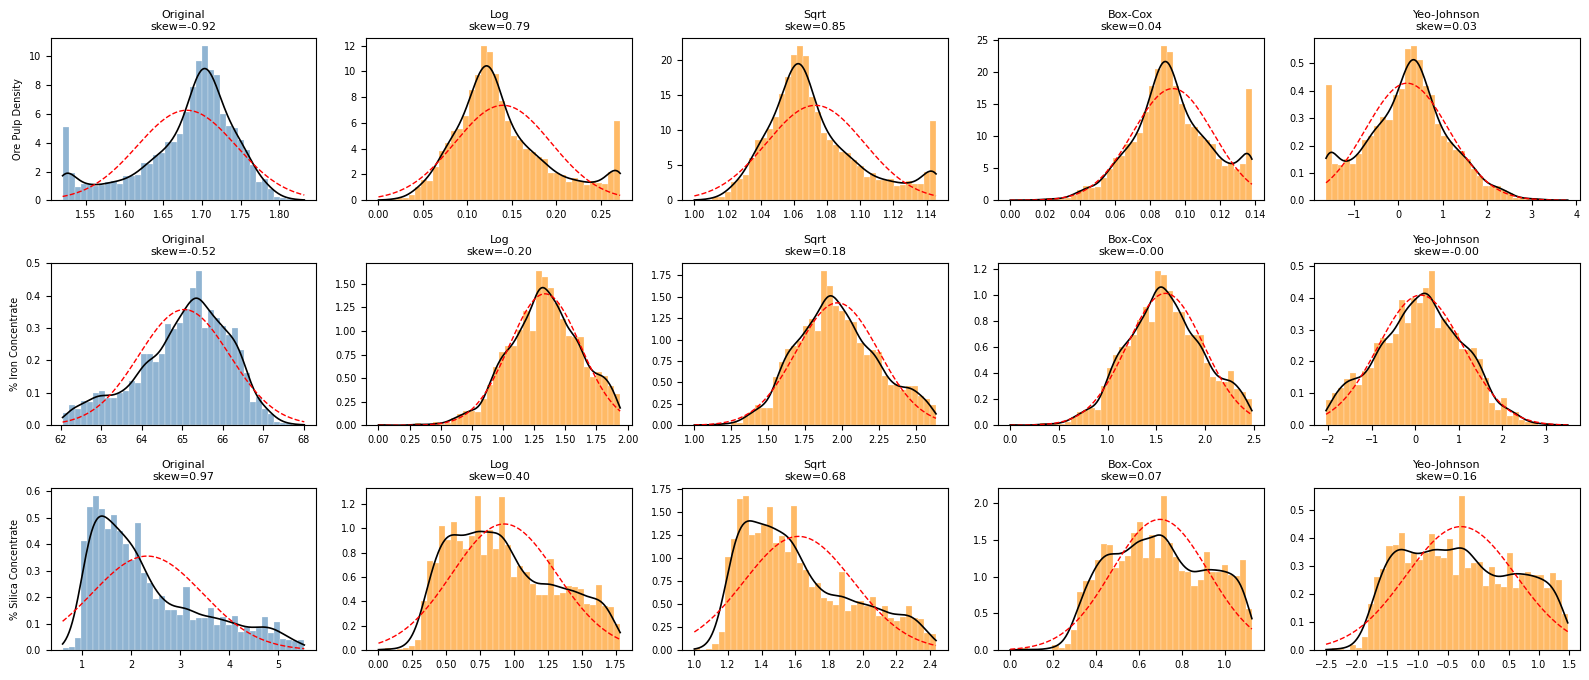

In [98]:
# Skewness treatment
# Se aplican 4 transformaciones a cada variable de hist_cols SIN modificar df (df sigue intacto):
#   log, raiz cuadrada, Box-Cox y Yeo-Johnson.
# - Log y raiz cuadrada solo reducen skew POSITIVO. Si la variable tiene skew negativo se
#   reflejan antes (-x) y despues se aplica la transformacion; el resultado queda
#   con el orden invertido, pero la forma de la distribucion es lo que se evalua aqui.
# - Se desplaza la variable para que x >= 1 (log y Box-Cox exigen x > 0).
#   Yeo-Johnson admite cualquier valor, pero se aplica sobre la variable
#   ESTANDARIZADA ((x - media) / std): con valores lejos de 0 y poca dispersion
#   relativa (p.ej. reactor_temp ~195 +- 0.6) el lambda optimo es extremo y la
#   salida queda practicamente constante (rango ~1e-15), sin informacion.
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, boxcox, yeojohnson, gaussian_kde, norm

def apply_skew_transforms(s):
    x = s.dropna()
    reflect = skew(x) < 0
    xp = -x if reflect else x
    xp = xp - xp.min() + 1.0
    out = {'Original': x}
    out['Log'] = np.log(xp)
    out['Sqrt'] = np.sqrt(xp)
    bc, lam_bc = boxcox(xp)
    out['Box-Cox'] = pd.Series(bc, index=x.index)
    yj, lam_yj = yeojohnson(((x - x.mean()) / x.std()).values)
    out['Yeo-Johnson'] = pd.Series(yj, index=x.index)
    return out, reflect, lam_bc, lam_yj

methods = ['Original', 'Log', 'Sqrt', 'Box-Cox', 'Yeo-Johnson']
transformed = {}   # {columna: {metodo: Serie}}
rows = []
for col in hist_cols:
    out, reflect, lam_bc, lam_yj = apply_skew_transforms(df[col])
    transformed[col] = out
    row = {'columna': col, 'reflejada': reflect}
    row.update({m: skew(out[m]) for m in methods})
    row['lambda_BoxCox'] = lam_bc
    row['lambda_YeoJohnson'] = lam_yj
    rows.append(row)

skew_compare = pd.DataFrame(rows).set_index('columna')
skew_compare['mejor_metodo'] = skew_compare[methods[1:]].abs().idxmin(axis=1)
display(skew_compare.round(3))
print('Skewness absoluto medio por metodo:')
print(skew_compare[methods].abs().mean().round(3))

# Histogramas: una fila por variable, una columna por metodo (en bloques de 6 variables)
# Linea negra continua = envolvente (KDE) | linea roja discontinua = normal con misma media y desviacion.
# Cuanto mas se parezca la envolvente a la normal, mas gaussiana es la distribucion.
block = 6
for start in range(0, len(hist_cols), block):
    cols_blk = hist_cols[start:start + block]
    fig, axes = plt.subplots(len(cols_blk), len(methods),
                             figsize=(3.2 * len(methods), 2.3 * len(cols_blk)))
    axes = np.atleast_2d(axes)
    for i, col in enumerate(cols_blk):
        for j, m in enumerate(methods):
            ax = axes[i, j]
            v = transformed[col][m]
            ax.hist(v, bins=40, density=True, color='steelblue' if j == 0 else 'darkorange',
                    edgecolor='white', linewidth=0.3, alpha=0.6)
            grid = np.linspace(v.min(), v.max(), 300)
            ax.plot(grid, gaussian_kde(v)(grid), color='black', lw=1.2)                    # envolvente (KDE)
            ax.plot(grid, norm.pdf(grid, v.mean(), v.std()), color='red', ls='--', lw=1)   # normal ajustada
            ax.set_title(f'{m}\nskew={skew(v):.2f}', fontsize=8)
            ax.tick_params(labelsize=7)
            if j == 0:
                ax.set_ylabel(col, fontsize=7)
    fig.tight_layout()
    plt.show()


# Noise filtering

In [99]:
# El filtrado de ruido opera sobre df_raw (crudo, cada 20s), no sobre df (agregado
# horario): el ruido de alta frecuencia que se quiere suavizar aqui ya desaparece
# solo al promediar por hora, asi que filtrar df horario no tendria sentido.

# --- EMA (alfa) filtering: causal, low-lag ---
# y[n] = alpha*x[n] + (1-alpha)*y[n-1]
# alpha equivalente a una media movil de "windowSize" en term de tiempo de asentamiento:
# alpha = 2 / (windowSize + 1) es la conversion estandar EMA <-> SMA
windowSize = 15
alpha = 2 / (windowSize + 1)

df_ema = df_raw[sensor_cols].ewm(alpha=alpha, adjust=False).mean()
for signal in sensor_cols:
    df_raw[signal + '_EMA'] = df_ema[signal]

# --- Savitzky-Golay causal ---
# El savgol_filter estandar es centrado (usa muestras futuras -> no es causal).
# Para hacerlo causal, se calculan los coeficientes SG evaluando el polinomio
# en el ULTIMO punto de la ventana (pos=windowSize-1) en vez del centro,
# y se aplican por convolucion (equivalente a "ajustar un polinomio a los
# ultimos N puntos y evaluar en el punto actual").
from scipy.signal import savgol_filter, savgol_coeffs

polyorder = 2
sg_causal_coeffs = savgol_coeffs(windowSize, polyorder, pos=windowSize - 1)

for signal in sensor_cols:
    # centrado, para comparar (usa muestras futuras, no valido en tiempo real)
    # mode='mirror': con el modo por defecto ('interp') los bordes se resuelven
    # ajustando un polinomio a las primeras/ultimas muestras, y un NaN ahi (los
    # primeros minutos que el relleno causal no cubre) rompe ese ajuste ('SVD did
    # not converge'). Con 'mirror' un NaN solo deja NaN en su propia ventana.
    df_raw[signal + '_SG'] = savgol_filter(df_raw[signal], window_length=windowSize,
                                           polyorder=polyorder, mode='mirror')
    # causal: convolucion con los coeficientes SG evaluados en el borde derecho
    df_raw[signal + '_SG_causal'] = np.convolve(df_raw[signal], sg_causal_coeffs, mode='full')[:len(df_raw)]


In [100]:
# import matplotlib.pyplot as plt
# import numpy as np

# # --- Selección de secciones random de 1 día (sobre df_raw: es donde viven los filtros) ---
# np.random.seed(42)  # quita esto si quieres aleatoriedad distinta cada vez
# n_sections = 2
# section_duration = pd.Timedelta(days=5)

# t_min = df_raw.index.min()
# t_max = df_raw.index.max() - section_duration

# if t_max <= t_min:
#     raise ValueError("El dataset dura menos de un día, no se pueden extraer secciones de 24h")

# section_starts = [
#     t_min + (t_max - t_min) * np.random.rand()
#     for _ in range(n_sections)
# ]

# # --- Graficado: una figura por señal ---
# for signal in sensor_cols:
#     fig, axes = plt.subplots(n_sections, 1, figsize=(12, 4 * n_sections))
#     if n_sections == 1:
#         axes = [axes]

#     for ax, start in zip(axes, section_starts):
#         end = start + section_duration
#         mask = (df_raw.index >= start) & (df_raw.index < end)

#         ax.plot(df_raw.index[mask], df_raw[signal][mask],
#                 label='Original', alpha=0.4, linewidth=1)
#         ax.plot(df_raw.index[mask], df_raw[signal + '_EMA'][mask],
#                 label=f'EMA causal (alpha={alpha:.3f})', linewidth=1.5)
#         # ax.plot(df_raw.index[mask], df_raw[signal + '_SG_causal'][mask],
#         #         label=f'Savitzky-Golay causal (w={windowSize})', linewidth=1.5)
#         # ax.plot(df_raw.index[mask], df_raw[signal + '_SG'][mask],
#         #         label=f'Savitzky-Golay centrado (w={windowSize}, no causal)',
#         #         linewidth=1, linestyle='--', alpha=0.7)

#         ax.set_title(f'{signal} | {start.strftime("%Y-%m-%d %H:%M")} → {end.strftime("%Y-%m-%d %H:%M")}')
#         ax.legend(loc='upper right', fontsize=8)
#         ax.grid(alpha=0.3)

#     plt.tight_layout()
#     plt.show()

# Variable Selection / Feature Selection

## Objetivos y formulación de la previsión

Se predice cada objetivo **h pasos hacia delante** usando solo información disponible en *t*:

- `y = objetivo(t + HORIZON)`
- `X = señales candidatas en t` (y `t-1`, `t-2`, ... si se añaden a `LAGS`)

Las candidatas son todas las `sensor_cols`, **incluidos los propios objetivos**: su
valor actual es información legítima para predecir su valor futuro, y una señal que
sirva para varios objetivos es justo lo que interesa encontrar.

Toda la selección se hace **solo con el tramo de train** (primer `TRAIN_FRAC`,
cronológico), para no usar el periodo de test al elegir variables.

In [101]:
# Objetivos, horizonte y datos para la seleccion de variables
TARGET_SIGNALS = ['% Silica Concentrate']
# Soft sensor: se estima la silice del concentrado EN t con las medidas de proceso
# en t (horizonte 0). Para predecir a futuro, poner p.ej. pd.Timedelta('1h').
HORIZON_TIME = pd.Timedelta('0h')   # horizonte de prevision, en tiempo
LAGS = [0]         # retardos de las entradas: [0] = valor en t; [0, 1, 2] = t, t-1, t-2
TRAIN_FRAC = 0.7   # la seleccion usa solo el primer 70% (cronologico)
n_select = 4       # entradas a seleccionar por objetivo en filtros y wrappers
FS_MAX_ROWS = 20_000   # filas maximas para los calculos caros (mutual info, RFE con RF)
assert 0 in LAGS, 'LAGS debe incluir 0 (valor actual de cada senal)'

# Horizonte en pasos de df segun su periodo de muestreo real (1 min sin
# remuestreo -> 15 pasos; si se remuestrea, se recalcula solo).
sample_period = df.index.to_series().diff().median()
HORIZON = int(round(HORIZON_TIME / sample_period))
assert HORIZON >= 0, f'HORIZON_TIME ({HORIZON_TIME}) menor que el muestreo ({sample_period})'
print(f'Muestreo: {sample_period} | horizonte: {HORIZON_TIME} = {HORIZON} pasos')


def short(name):
    """'B_R1__reactor_temp@t' -> 'reactor_temp@t' (nombres legibles en tablas)."""
    return name.split('__')[-1]


target_cols = [c for c in sensor_cols if short(c) in TARGET_SIGNALS]
missing_targets = set(TARGET_SIGNALS) - {short(c) for c in target_cols}
assert not missing_targets, f'Objetivos que no estan en sensor_cols: {missing_targets}'
# Entradas que NO se usan: el propio objetivo (con horizonte 0 seria trivial) y
# % Iron Concentrate (otro resultado del mismo analisis de laboratorio: fuga de informacion).
EXCLUDE_FROM_INPUTS = ['% Iron Concentrate']
candidate_cols = [c for c in sensor_cols if c not in target_cols and short(c) not in EXCLUDE_FROM_INPUTS]


def make_forecast_xy(data, target, features, horizon=HORIZON, lags=LAGS):
    """X: entradas retrasadas ('<senal>@t', '<senal>@t-k'); y: objetivo adelantado h pasos."""
    X = pd.concat({(f'{f}@t-{k}' if k else f'{f}@t'): data[f].shift(k)
                   for f in features for k in lags}, axis=1)
    y = data[target].shift(-horizon).rename(f'{target}@t+{horizon}')
    xy = pd.concat([X, y], axis=1).dropna()
    return xy[X.columns], xy[y.name]


def thin(X, y, max_rows=FS_MAX_ROWS):
    """Submuestreo regular (1 de cada k filas) para los calculos caros. A 1 min
    las filas consecutivas son casi redundantes; se conserva el orden temporal."""
    step = max(1, int(np.ceil(len(X) / max_rows)))
    return X.iloc[::step], y.iloc[::step]


n_train = int(len(df) * TRAIN_FRAC)
df_fs = df.iloc[:n_train]
fs_xy = {t: make_forecast_xy(df_fs, t, candidate_cols) for t in target_cols}
print(f'Train para seleccion: {df_fs.index.min()} -> {df_fs.index.max()} ({n_train} filas)')
print(f'Objetivos ({len(target_cols)}): {[short(t) for t in target_cols]}')
print(f'Entradas candidatas: {len(candidate_cols)} senales x {len(LAGS)} retardos')

# Resumen del objetivo en el tramo de train
pd.DataFrame({short(t): fs_xy[t][1].describe() for t in target_cols}).round(4)


Muestreo: 0 days 01:00:00 | horizonte: 0 days 00:00:00 = 0 pasos
Train para seleccion: 2017-03-10 01:00:00 -> 2017-07-16 18:00:00 (3090 filas)
Objetivos (1): ['% Silica Concentrate']
Entradas candidatas: 7 senales x 1 retardos


,% Silica Concentrate
count,2772.0000
mean,2.3372
std,1.1300
min,0.7700
25%,1.4400
50%,1.9900
75%,3.1000
max,5.5100


# Filter methods

In [102]:
# Filtro lineal: r de Pearson de cada entrada con cada objetivo(t+h).
# (El ranking de f_regression es identico al de |r|: F = r^2/(1-r^2)*(n-2) crece
# con n y solo indica significancia; r y r^2 dan la magnitud interpretable.)
r_matrix = pd.DataFrame({
    short(t): fs_xy[t][0].corrwith(fs_xy[t][1]) for t in target_cols
}).rename(index=short)    # filas: entradas | columnas: objetivos

print(f'r de Pearson: entrada vs objetivo(t+{HORIZON})')
r_matrix.round(3)

r de Pearson: entrada vs objetivo(t+0)


,% Silica Concentrate
% Iron Feed@t,-0.081
% Silica Feed@t,0.075
Starch Flow@t,-0.125
Amina Flow@t,0.103
Ore Pulp Flow@t,0.013
Ore Pulp pH@t,-0.158
Ore Pulp Density@t,0.053


In [103]:
# Mutual information: capta dependencias no lineales que Pearson no ve
from sklearn.feature_selection import mutual_info_regression

mi_matrix = pd.DataFrame({
    # submuestreo: el estimador por vecinos es lento con ~90k filas
    short(t): pd.Series(mutual_info_regression(*thin(*fs_xy[t]), random_state=42),
                        index=fs_xy[t][0].columns)
    for t in target_cols
}).rename(index=short)

print(f'Mutual information: entrada vs objetivo(t+{HORIZON})')
mi_matrix.round(3)

Mutual information: entrada vs objetivo(t+0)


,% Silica Concentrate
% Iron Feed@t,0.379
% Silica Feed@t,0.402
Starch Flow@t,0.032
Amina Flow@t,0.064
Ore Pulp Flow@t,0.000
Ore Pulp pH@t,0.045
Ore Pulp Density@t,0.113


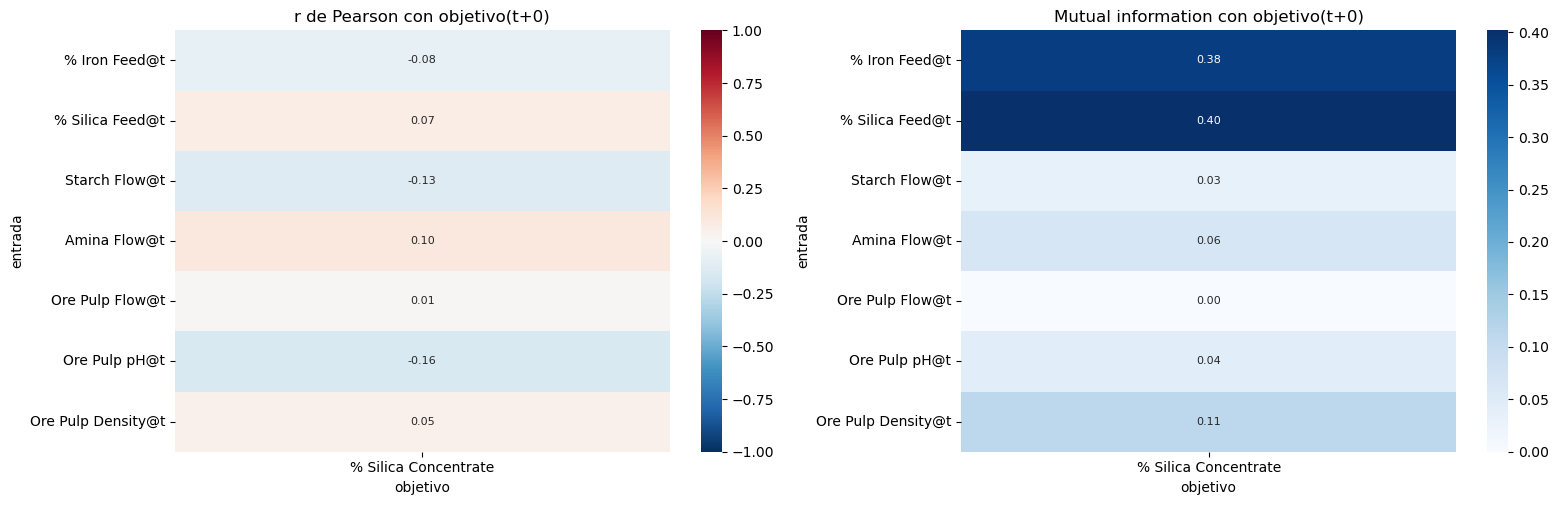

,top4 |r|,top4 MI
% Silica Concentrate,"Ore Pulp pH@t, Starch Flow@t, Amina Flow@t, % ...","% Silica Feed@t, % Iron Feed@t, Ore Pulp Densi..."


In [104]:
# Comparacion lineal (r) vs no lineal (MI): mapas entradas x objetivos y top-n
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 0.45 * len(r_matrix) + 2))
sns.heatmap(r_matrix, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
            ax=axes[0], annot_kws={'size': 8})
axes[0].set_title(f'r de Pearson con objetivo(t+{HORIZON})')
sns.heatmap(mi_matrix, annot=True, fmt='.2f', cmap='Blues', vmin=0,
            ax=axes[1], annot_kws={'size': 8})
axes[1].set_title(f'Mutual information con objetivo(t+{HORIZON})')
for ax in axes:
    ax.set_xlabel('objetivo')
    ax.set_ylabel('entrada')
plt.tight_layout()
plt.show()

top_r = {t: r_matrix[t].abs().nlargest(n_select).index.tolist() for t in r_matrix}
top_mi = {t: mi_matrix[t].nlargest(n_select).index.tolist() for t in mi_matrix}
comparison = pd.DataFrame({
    f'top{n_select} |r|': {t: ', '.join(v) for t, v in top_r.items()},
    f'top{n_select} MI': {t: ', '.join(v) for t, v in top_mi.items()},
})
comparison

## Colinealidad entre entradas

Dos entradas muy correladas entre sí aportan casi la misma información: basta con
una, y meter las dos solo hace inestables los coeficientes de un modelo lineal.

La correlación se calcula sobre la **media móvil causal de `COLLINEAR_SMOOTH_STEPS`
muestras** (por defecto, el horizonte: 15 min). A 1 min el ruido propio de cada
sensor oculta relaciones reales (p. ej. `feed_flow_rate` ~ `conversion_rate`: r = 0.66
a 1 min, 0.96 con media de 15 min) y crea otras que solo son ruido compartido; para
una previsión a 15 min importa la relación a esa escala.

- **Mapa de correlación agrupado**: los bloques de señales que se mueven juntas
  quedan contiguos.
- **Pares con |r| ≥ `COLLINEAR_R`**: candidatos a quedarse solo con una.
- **VIF** (*variance inflation factor*) = 1 / (1 − R²) de cada entrada explicada por
  las demás. VIF > 10 suele considerarse colinealidad fuerte.

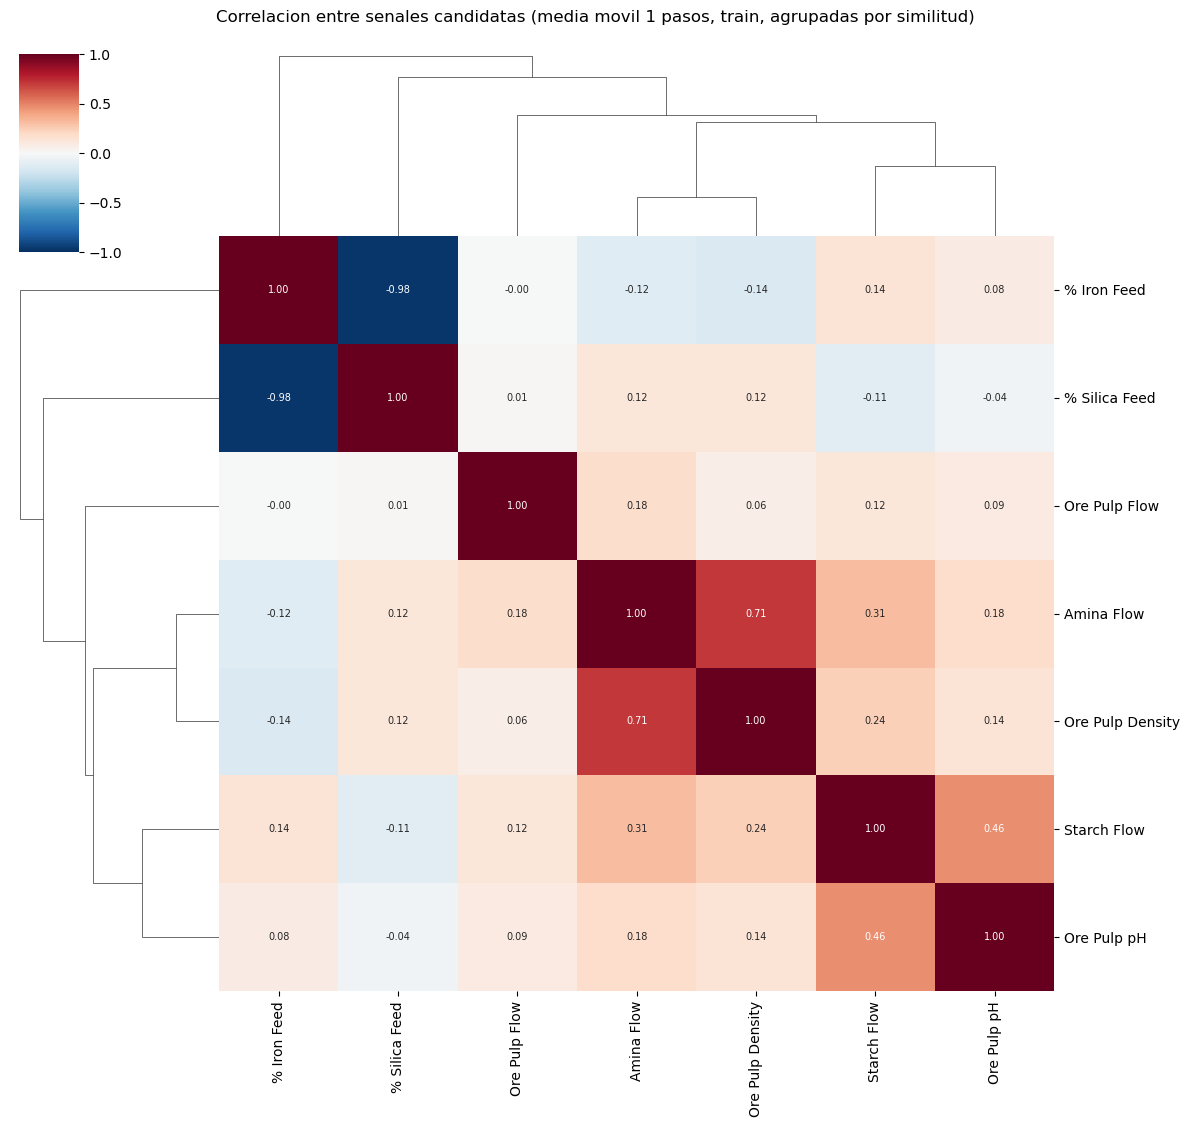

Pares con |r| >= 0.8:


,,r
senal_1,senal_2,
% Iron Feed,% Silica Feed,-0.976


VIF de cada senal frente a las demas (> 10 = colinealidad fuerte):


,VIF
% Iron Feed,22.4
% Silica Feed,22.1
Amina Flow,2.2
Ore Pulp Density,2.1
Starch Flow,1.4
Ore Pulp pH,1.3
Ore Pulp Flow,1.0


In [105]:
# Colinealidad entre las senales candidatas (en t, tramo de train)
from sklearn.linear_model import LinearRegression

COLLINEAR_R = 0.8
COLLINEAR_SMOOTH_STEPS = max(HORIZON, 1)   # media movil causal (solo pasado); 1 = sin suavizar


def smooth(data, steps=COLLINEAR_SMOOTH_STEPS):
    """Media movil causal: escala temporal a la que se juzga la colinealidad."""
    return data.rolling(steps, min_periods=steps).mean()


collin_data = smooth(df_fs[candidate_cols]).dropna()

corr_inputs = collin_data.corr().rename(index=short, columns=short)
cg = sns.clustermap(corr_inputs, cmap='RdBu_r', vmin=-1, vmax=1, annot=True, fmt='.2f',
                    annot_kws={'size': 7}, figsize=(12, 11))
cg.figure.suptitle(f'Correlacion entre senales candidatas (media movil {COLLINEAR_SMOOTH_STEPS} pasos, '
                   'train, agrupadas por similitud)', y=1.02)
plt.show()

upper = np.triu(np.ones(corr_inputs.shape, dtype=bool), k=1)
pairs = corr_inputs.where(upper).stack()
pairs.index.names = ['senal_1', 'senal_2']
collinear_pairs = pairs[pairs.abs() >= COLLINEAR_R].sort_values(key=abs, ascending=False)
print(f'Pares con |r| >= {COLLINEAR_R}:')
display(collinear_pairs.round(3).to_frame('r'))

X_vif = collin_data
vif = {}
for c in candidate_cols:
    others = X_vif.drop(columns=c)
    r2 = LinearRegression().fit(others, X_vif[c]).score(others, X_vif[c])
    vif[short(c)] = 1 / max(1 - r2, 1e-12)
vif = pd.Series(vif).sort_values(ascending=False)
print('VIF de cada senal frente a las demas (> 10 = colinealidad fuerte):')
vif.round(1).to_frame('VIF')

## Relación de los objetivos con las variables corregidas de skewness

Para cada objetivo(t+h) y cada entrada (en *t*) se compara el r² con la variable
original y con cada transformación de la sección *Skewness treatment*.

- **r²** mide relación **lineal**: es lo único que cambia con la transformación.
  Si sube, la transformación hace la relación más lineal (útil para modelos lineales).
- Solo se transforman las entradas; el objetivo se deja en su escala original.

In [106]:
# Relacion objetivo(t+h) vs entradas transformadas (correccion de skewness), en t.
# Usa `transformed` y `skew_compare` de "Skewness treatment". Las variables
# reflejadas (skew negativo) tienen el orden invertido en Log/Sqrt/Box-Cox: se les
# devuelve el signo para que r sea comparable con la original.
# OJO: lambdas ajustados con todo el historico -> exploratorio; para modelar, ajustarlos solo con train.
from scipy.stats import pearsonr

rel_rows = []
for t in target_cols:
    y_future = df_fs[t].shift(-HORIZON).rename('y')
    for col in candidate_cols:
        reflected = skew_compare.loc[col, 'reflejada']
        for m in methods:
            v = transformed[col][m]
            if reflected and m in ('Log', 'Sqrt', 'Box-Cox'):
                v = -v
            pair = pd.concat([v.rename('x'), y_future], axis=1).dropna()
            rel_rows.append({'objetivo': short(t), 'entrada': short(col), 'metodo': m,
                             'r2': pearsonr(pair['x'], pair['y'])[0] ** 2})
rel_transformed = pd.DataFrame(rel_rows)

r2_original = rel_transformed[rel_transformed['metodo'] == 'Original'].pivot(
    index='entrada', columns='objetivo', values='r2')
best = rel_transformed.loc[rel_transformed.groupby(['entrada', 'objetivo'])['r2'].idxmax()]
r2_gain = best.pivot(index='entrada', columns='objetivo', values='r2') - r2_original
best_method = best.pivot(index='entrada', columns='objetivo', values='metodo')

print('r^2 con la variable original:')
display(r2_original.round(3))
print('Ganancia de r^2 con la mejor transformacion (0 = ninguna mejora a la original):')
display(r2_gain.round(4))
print('Mejor transformacion por entrada y objetivo:')
best_method

r^2 con la variable original:


objetivo,% Silica Concentrate
entrada,
% Iron Feed,0.007
% Silica Feed,0.006
Amina Flow,0.011
Ore Pulp Density,0.003
Ore Pulp Flow,0.000
Ore Pulp pH,0.025
Starch Flow,0.016


Ganancia de r^2 con la mejor transformacion (0 = ninguna mejora a la original):


objetivo,% Silica Concentrate
entrada,
% Iron Feed,0.0000
% Silica Feed,0.0047
Amina Flow,0.0020
Ore Pulp Density,0.0030
Ore Pulp Flow,0.0004
Ore Pulp pH,0.0006
Starch Flow,0.0000


Mejor transformacion por entrada y objetivo:


objetivo,% Silica Concentrate
entrada,
% Iron Feed,Original
% Silica Feed,Log
Amina Flow,Yeo-Johnson
Ore Pulp Density,Yeo-Johnson
Ore Pulp Flow,Log
Ore Pulp pH,Log
Starch Flow,Original


# Wrapper methods

In [107]:
# Wrapper 1: Backward SFS con LinearRegression, un ajuste por objetivo.
# Validacion cruzada TEMPORAL (TimeSeriesSplit): cada pliegue valida con datos
# posteriores a los de ajuste, como en la prevision real (KFold usaria el futuro
# para validar el pasado).
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import make_pipeline

tscv = TimeSeriesSplit(n_splits=5)

bsfs_selected = {}
for t in target_cols:
    X_t, y_t = fs_xy[t]
    sfs = SequentialFeatureSelector(
        make_pipeline(StandardScaler(), LinearRegression()),
        n_features_to_select=n_select, direction='backward', cv=tscv,
    ).fit(X_t, y_t)
    bsfs_selected[short(t)] = [short(c) for c in X_t.columns[sfs.get_support()]]
    print(f'{short(t):18s} BSFS: {bsfs_selected[short(t)]}')

% Silica Concentrate BSFS: ['Starch Flow@t', 'Amina Flow@t', 'Ore Pulp Flow@t', 'Ore Pulp pH@t']


In [108]:
# Wrapper 2: RFE con LinearRegression (mismo estimador que BSFS). Elimina la
# entrada de menor |coeficiente| en cada paso, por eso aqui SI hay que estandarizar:
# sin escalar, los coeficientes dependen de las unidades de cada senal.
from sklearn.feature_selection import RFE

rfe_selected = {}
for t in target_cols:
    X_t, y_t = fs_xy[t]
    rfe = RFE(LinearRegression(), n_features_to_select=n_select).fit(
        StandardScaler().fit_transform(X_t), y_t)
    rfe_selected[short(t)] = [short(c) for c in X_t.columns[rfe.get_support()]]
    print(f'{short(t):18s} RFE: {rfe_selected[short(t)]}')

% Silica Concentrate RFE: ['% Silica Feed@t', 'Starch Flow@t', 'Amina Flow@t', 'Ore Pulp pH@t']


In [109]:
# Comparacion por objetivo: BSFS (evalua por CV) vs RFE (elimina por coeficiente)
bsfs_vs_rfe = pd.DataFrame({
    t: {
        'coinciden': ', '.join(sorted(set(bsfs_selected[t]) & set(rfe_selected[t]))),
        'solo BSFS': ', '.join(sorted(set(bsfs_selected[t]) - set(rfe_selected[t]))),
        'solo RFE': ', '.join(sorted(set(rfe_selected[t]) - set(bsfs_selected[t]))),
    } for t in bsfs_selected
}).T
bsfs_vs_rfe

,coinciden,solo BSFS,solo RFE
% Silica Concentrate,"Amina Flow@t, Ore Pulp pH@t, Starch Flow@t",Ore Pulp Flow@t,% Silica Feed@t


### ¿Es apropiado usar un modelo lineal para el wrapper?

BSFS y RFE con `LinearRegression` solo pueden premiar relaciones lineales. Si en la
comparación *Pearson vs mutual information* alguna entrada tiene MI alta pero |r| bajo,
su relación con el objetivo es no lineal y un wrapper lineal la descartará. Se repite
el RFE con `RandomForestRegressor` (capta no linealidad e interacciones y no necesita
escalado) para comparar.

In [110]:
# Wrapper 3: RFE con RandomForestRegressor (no lineal, capta interacciones).
# No hace falta escalar: los arboles son invariantes a la escala de las entradas.
from sklearn.ensemble import RandomForestRegressor

# Coste: n_objetivos x (n_entradas - n_select) ajustes de un bosque completo. Con
# 20k filas y arboles sin limite tardaba ~10 min; para ORDENAR entradas basta con
# menos filas, menos arboles y profundidad acotada.
RF_MAX_ROWS = 5_000

rfe_rf_selected = {}
for t in target_cols:
    X_t, y_t = thin(*fs_xy[t], max_rows=RF_MAX_ROWS)
    rfe_rf = RFE(RandomForestRegressor(n_estimators=50, max_depth=12, min_samples_leaf=5,
                                       random_state=42, n_jobs=-1),
                 n_features_to_select=n_select).fit(X_t, y_t)
    rfe_rf_selected[short(t)] = [short(c) for c in X_t.columns[rfe_rf.get_support()]]
    print(f'{short(t):18s} RFE RF: {rfe_rf_selected[short(t)]}')

% Silica Concentrate RFE RF: ['% Silica Feed@t', 'Starch Flow@t', 'Amina Flow@t', 'Ore Pulp pH@t']


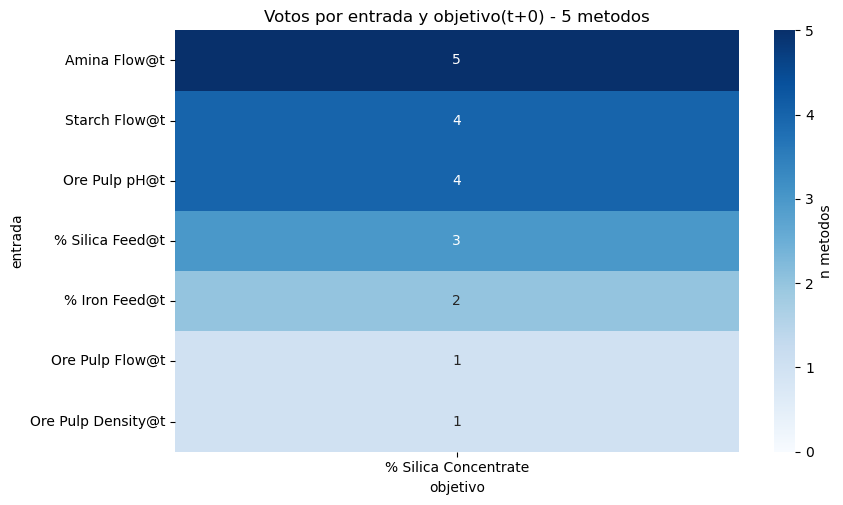

,% Silica Concentrate,n_objetivos (>= 3 votos),votos_totales
Amina Flow@t,5,1,5
Starch Flow@t,4,1,4
Ore Pulp pH@t,4,1,4
% Silica Feed@t,3,1,3
% Iron Feed@t,2,0,2
Ore Pulp Flow@t,1,0,1
Ore Pulp Density@t,1,0,1


In [111]:
# Resumen: cuantos metodos (de 5) eligen cada entrada para cada objetivo.
# Una entrada con muchos votos en VARIAS columnas sirve para predecir varios
# objetivos a la vez; cruzarlo con la colinealidad de arriba para no quedarse con
# dos entradas redundantes.
selections = {
    f'top{n_select} |r|': top_r,
    f'top{n_select} MI': top_mi,
    'BSFS lineal': bsfs_selected,
    'RFE lineal': rfe_selected,
    'RFE RF': rfe_rf_selected,
}
votes = pd.DataFrame(0, index=r_matrix.index, columns=r_matrix.columns)
for sel in selections.values():
    for t, feats in sel.items():
        votes.loc[feats, t] += 1

VOTES_MIN = 3   # votos para considerar una entrada relevante para un objetivo
votes_summary = votes.copy()
votes_summary[f'n_objetivos (>= {VOTES_MIN} votos)'] = (votes >= VOTES_MIN).sum(axis=1)
votes_summary['votos_totales'] = votes.sum(axis=1)
votes_summary = votes_summary.sort_values(
    [f'n_objetivos (>= {VOTES_MIN} votos)', 'votos_totales'], ascending=False)

fig, ax = plt.subplots(figsize=(9, 0.45 * len(votes) + 2))
sns.heatmap(votes.loc[votes_summary.index], annot=True, fmt='d', cmap='Blues',
            vmin=0, vmax=len(selections), ax=ax, cbar_kws={'label': 'n metodos'})
ax.set_title(f'Votos por entrada y objetivo(t+{HORIZON}) - {len(selections)} metodos')
ax.set_xlabel('objetivo')
ax.set_ylabel('entrada')
plt.tight_layout()
plt.show()

wrapper_comparison = votes_summary   # nombre usado por la matriz scatter de abajo
votes_summary

## Selección final de entradas (sin colinealidad)

A partir de los votos de los 5 métodos:

1. **Por objetivo**: se recorren las entradas de más a menos votos (desempate por
   |r| con el objetivo) y se acepta una solo si su |r| con todas las ya aceptadas
   es menor que `COLLINEAR_R`. Máximo `n_select` entradas, mínimo `MIN_VOTES` votos.
2. **Conjunto común**: unión de las anteriores, priorizando las que sirven a más
   objetivos, con el mismo filtro de colinealidad. Una señal que sirve para dos
   objetivos sustituye a dos señales redundantes.

`EXCLUDE_FROM_INPUTS` deja fuera señales que no deben usarse como entrada
(etiquetas o diagnósticos no disponibles en tiempo real).

In [112]:
# Seleccion final de entradas por objetivo y conjunto comun, sin colinealidad
MIN_VOTES = 2   # votos minimos (de 5 metodos) para que una entrada sea candidata

feature_full = {short(c): c for c in fs_xy[target_cols[0]][0].columns}   # 'x@t' -> 'B_R1__x@t'
excluded = {f for f in votes.index if f.split('@')[0] in EXCLUDE_FROM_INPUTS}

# |r| entre entradas (con sus retardos si LAGS tiene varios), tramo de train, a la
# misma escala que la seccion de colinealidad (media movil causal)
corr_feat = smooth(fs_xy[target_cols[0]][0]).dropna().rename(columns=short).corr().abs()


def pick_non_collinear(ranked, max_n):
    """Recorre `ranked` en orden y acepta cada entrada si no es colineal con las ya
    aceptadas. Devuelve (aceptadas, {descartada: aceptada con la que choca})."""
    chosen, dropped = [], {}
    for f in ranked:
        if len(chosen) >= max_n:
            break
        clash = [c for c in chosen if corr_feat.loc[f, c] >= COLLINEAR_R]
        if clash:
            dropped[f] = clash[0]
        else:
            chosen.append(f)
    return chosen, dropped


# 1) Por objetivo
selected_inputs, rows = {}, []
for t in votes.columns:
    cand = votes[t][(votes[t] >= MIN_VOTES) & ~votes.index.isin(excluded)]
    ranked = sorted(cand.index, key=lambda f: (-cand[f], -abs(r_matrix.loc[f, t])))
    chosen, dropped = pick_non_collinear(ranked, n_select)
    selected_inputs[t] = chosen
    rows.append({
        'objetivo': t,
        'entradas': ', '.join(f'{f} ({votes.loc[f, t]})' for f in chosen),
        'descartadas por colinealidad': ', '.join(f'{f} ~ {c}' for f, c in dropped.items()),
    })
print(f'Entradas por objetivo (t + {HORIZON_TIME.total_seconds() / 60:g} min) - entre parentesis, votos:')
display(pd.DataFrame(rows).set_index('objetivo'))

# 2) Conjunto comun: primero las que sirven a mas objetivos
n_targets_using = pd.Series({f: sum(f in v for v in selected_inputs.values()) for f in votes.index})
union = [f for f in votes.index if n_targets_using[f] > 0]
ranked_union = sorted(union, key=lambda f: (-n_targets_using[f], -votes.loc[f].sum()))
shared_inputs, shared_dropped = pick_non_collinear(ranked_union, len(ranked_union))

# Que entradas del conjunto comun usa cada objetivo (una descartada se sustituye
# por la entrada comun con la que es colineal)
coverage = pd.Series({
    t: ', '.join(dict.fromkeys(shared_dropped.get(f, f) for f in feats))
    for t, feats in selected_inputs.items()
}, name='entradas (conjunto comun)')

final_input_cols = [feature_full[f] for f in shared_inputs]
final_input_signals = list(dict.fromkeys(c.split('@')[0] for c in final_input_cols))
print(f'Conjunto comun ({len(shared_inputs)}): {shared_inputs}')
print('Sustituidas por colinealidad:', {f: c for f, c in shared_dropped.items()} or 'ninguna')
print('Senales de entrada (final_input_signals):', [short(s) for s in final_input_signals])
coverage.to_frame()

Entradas por objetivo (t + 0 min) - entre parentesis, votos:


,entradas,descartadas por colinealidad
objetivo,,
% Silica Concentrate,"Amina Flow@t (5), Ore Pulp pH@t (4), Starch Fl...",


Conjunto comun (4): ['Amina Flow@t', 'Starch Flow@t', 'Ore Pulp pH@t', '% Silica Feed@t']
Sustituidas por colinealidad: ninguna
Senales de entrada (final_input_signals): ['Amina Flow', 'Starch Flow', 'Ore Pulp pH', '% Silica Feed']


,entradas (conjunto comun)
% Silica Concentrate,"Amina Flow@t, Ore Pulp pH@t, Starch Flow@t, % ..."


# Objetivos vs entradas más votadas

# Scatter matrix: entradas elegidas (t) vs objetivo

2772 filas | variables: ['% Silica Feed(t)', 'Starch Flow(t)', 'Amina Flow(t)', 'Ore Pulp pH(t)', '% Silica Concentrate(t+0)']


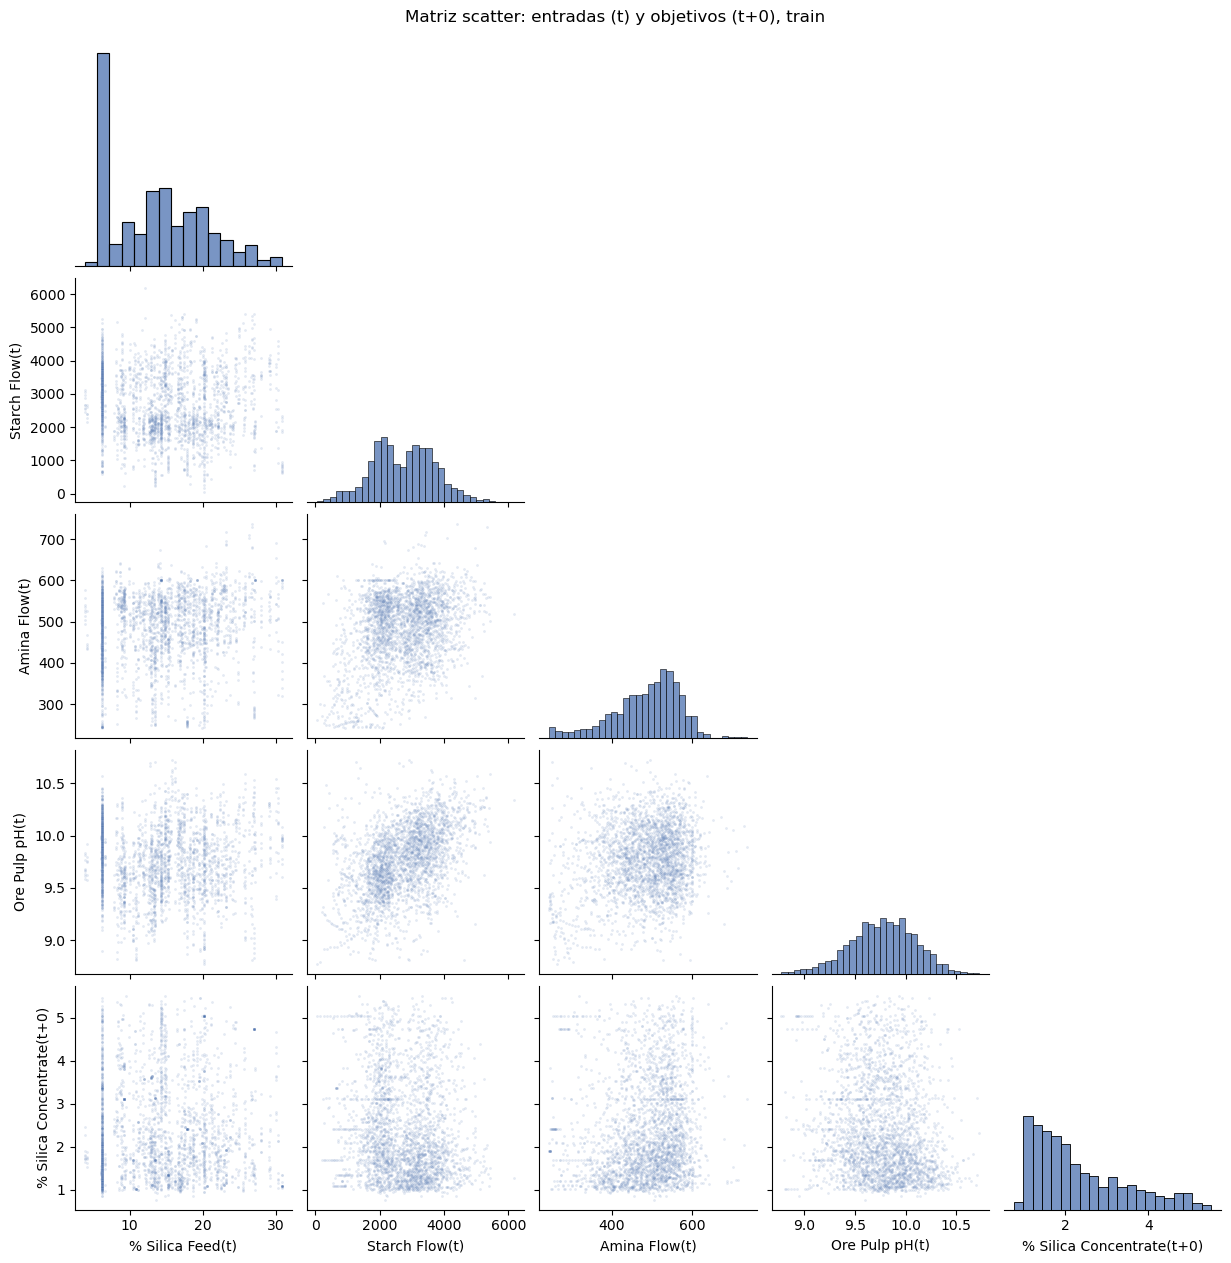

In [113]:
# Matriz scatter para la prevision a SCATTER_HORIZON_TIME (tramo de train):
# entradas elegidas en t y objetivos en t+h.
# - entrada vs entrada (mismo t): colinealidad entre las entradas.
# - entrada vs objetivo: la relacion que tendria que aprovechar el modelo.
import seaborn as sns

SCATTER_HORIZON_TIME = HORIZON_TIME
SCATTER_HORIZON = int(round(SCATTER_HORIZON_TIME / sample_period))   # en pasos de df
SCATTER_MAX_POINTS = 10_000   # puntos dibujados (las correlaciones usan todas las filas)
SCATTER_INPUT_SIGNALS = [short(c) for c in final_input_signals][:6]   # las elegidas en la seleccion final

scatter_input_cols = [c for c in candidate_cols if short(c) in SCATTER_INPUT_SIGNALS]
missing_inputs = set(SCATTER_INPUT_SIGNALS) - {short(c) for c in scatter_input_cols}
assert not missing_inputs, f'Entradas que no estan en candidate_cols: {missing_inputs}'


def forecast_frame(data, inputs, targets, horizon):
    """Entradas en t ('<senal>(t)') y objetivos en t+h ('<objetivo>(t+h)'), sin NaN."""
    X = data[inputs].rename(columns=lambda c: f'{short(c)}(t)')
    Y = data[targets].shift(-horizon).rename(columns=lambda c: f'{short(c)}(t+{horizon})')
    return pd.concat([X, Y], axis=1).dropna()


scatter_matrix_data = forecast_frame(df_fs, scatter_input_cols, target_cols, SCATTER_HORIZON)
print(f'{len(scatter_matrix_data)} filas | variables: {list(scatter_matrix_data.columns)}')

g = sns.pairplot(
    thin(scatter_matrix_data, scatter_matrix_data, SCATTER_MAX_POINTS)[0],
    corner=True,  # solo mitad inferior, evita paneles duplicados/espejados
    plot_kws={'s': 4, 'alpha': 0.15, 'color': '#4C72B0'},
    diag_kws={'color': '#4C72B0'},
)
g.figure.suptitle(f'Matriz scatter: entradas (t) y objetivos (t+{SCATTER_HORIZON}), train', y=1.01)
plt.show()

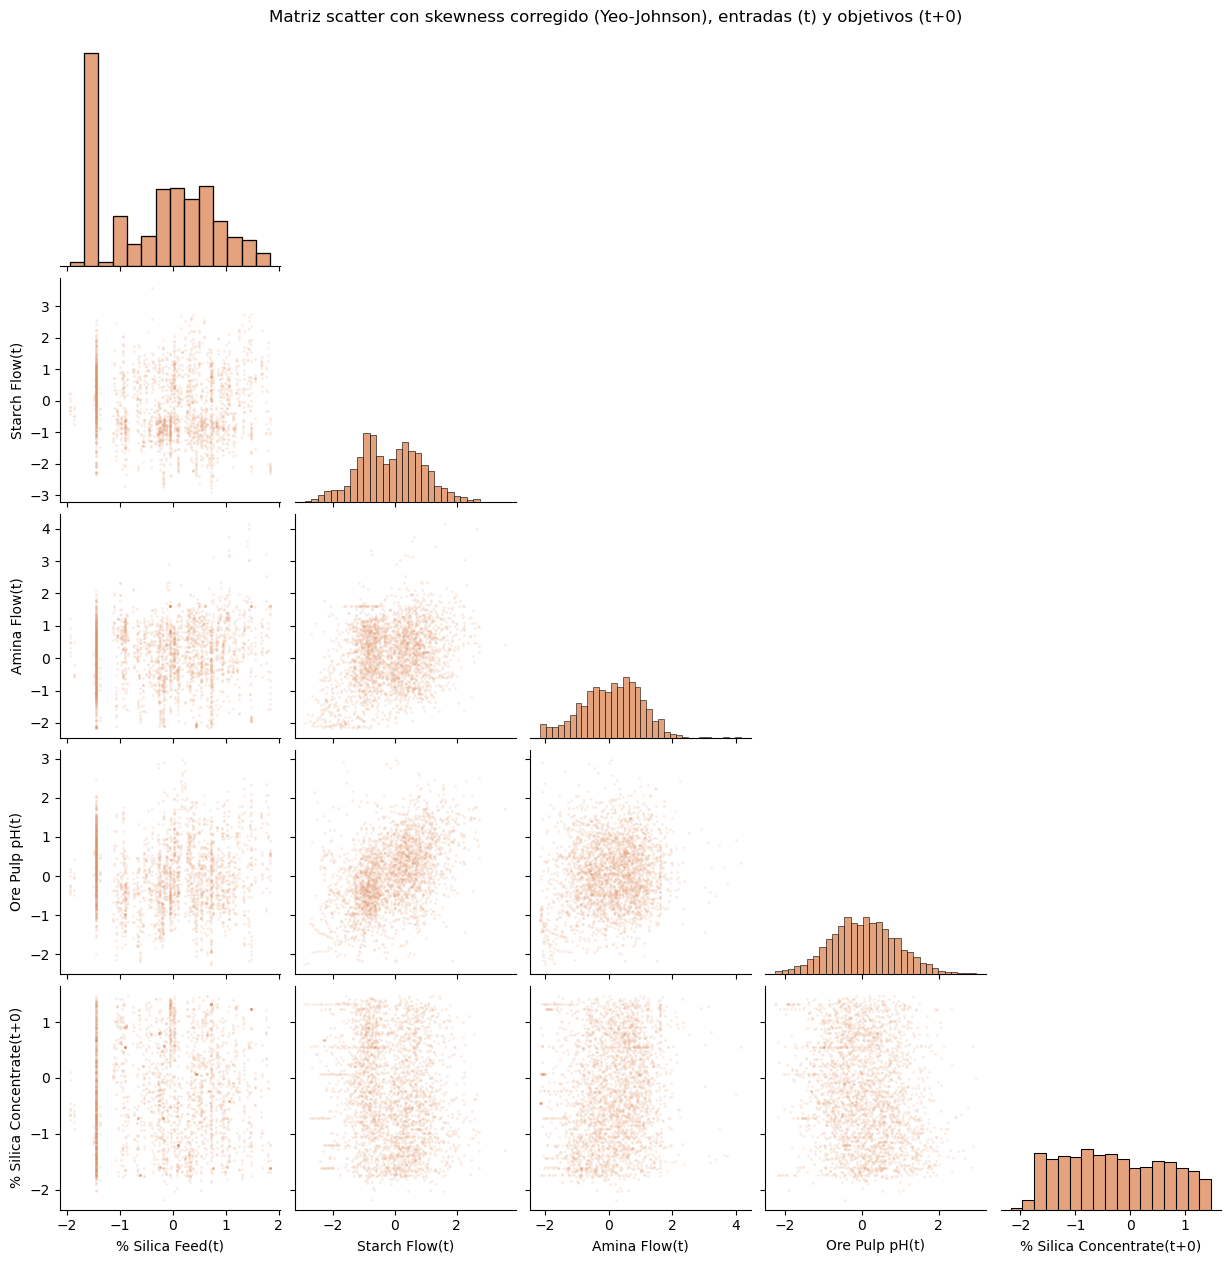

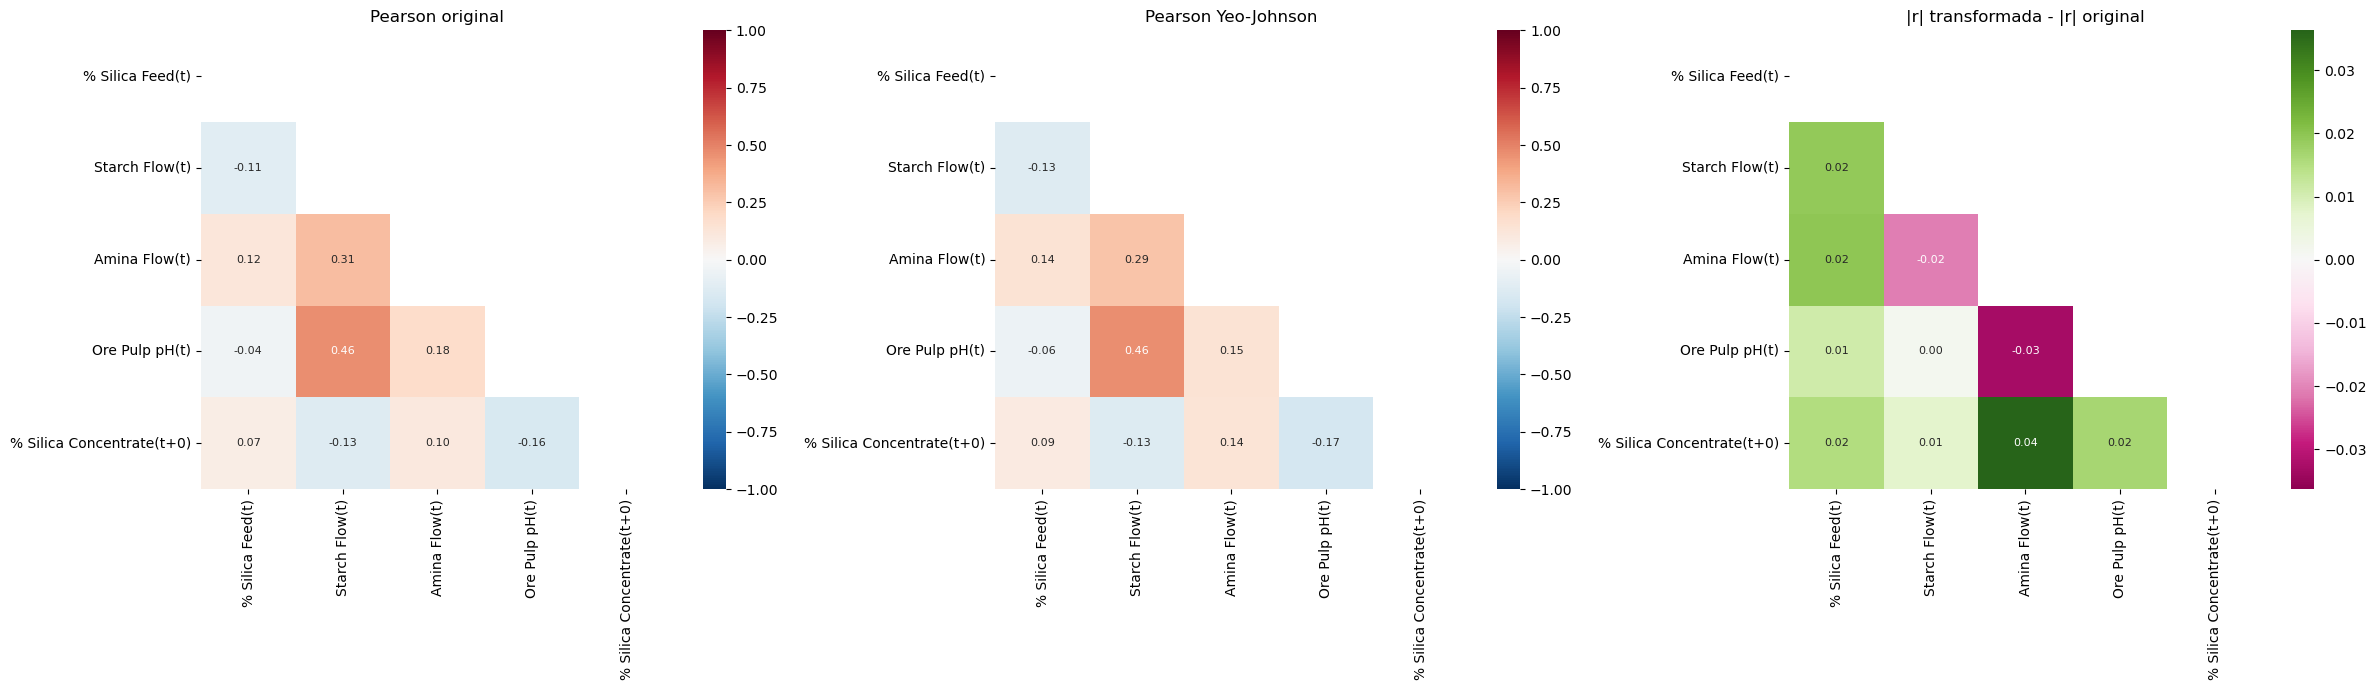

In [114]:
# Misma matriz scatter pero con las variables corregidas de skewness, para comparar
# con la de arriba. Se usa Yeo-Johnson por defecto: no necesita reflejar ni desplazar,
# asi que conserva el orden/signo de las relaciones.
# Cambiar scatter_method a 'Log', 'Sqrt' o 'Box-Cox' para ver los otros.
# Se transforman entradas y objetivos, y despues se desplazan los objetivos h pasos.
scatter_method = 'Yeo-Johnson'

def transformed_col(col, method):
    v = transformed[col][method]
    # variables reflejadas (skew negativo): se devuelve el signo para no invertir la relacion
    if skew_compare.loc[col, 'reflejada'] and method in ('Log', 'Sqrt', 'Box-Cox'):
        v = -v
    return v

transformed_df = pd.DataFrame({
    c: transformed_col(c, scatter_method) for c in dict.fromkeys(scatter_input_cols + target_cols)
}).reindex(df_fs.index)
scatter_matrix_data_tr = forecast_frame(transformed_df, scatter_input_cols, target_cols,
                                        SCATTER_HORIZON)

g_tr = sns.pairplot(
    thin(scatter_matrix_data_tr, scatter_matrix_data_tr, SCATTER_MAX_POINTS)[0],
    corner=True,
    plot_kws={'s': 4, 'alpha': 0.15, 'color': '#DD8452'},
    diag_kws={'color': '#DD8452'},
)
g_tr.figure.suptitle(f'Matriz scatter con skewness corregido ({scatter_method}), '
                     f'entradas (t) y objetivos (t+{SCATTER_HORIZON})', y=1.01)
plt.show()

# Comparacion numerica: correlacion de Pearson original vs transformada.
# Si |r| sube tras transformar, la relacion se ha vuelto mas lineal.
corr_orig = scatter_matrix_data.corr()
corr_tr = scatter_matrix_data_tr.corr()
corr_diff = corr_tr.abs() - corr_orig.abs()

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
for ax, mat, title, cmap, lim in [
    (axes[0], corr_orig, 'Pearson original', 'RdBu_r', 1),
    (axes[1], corr_tr, f'Pearson {scatter_method}', 'RdBu_r', 1),
    (axes[2], corr_diff, '|r| transformada - |r| original', 'PiYG', np.abs(corr_diff.values).max()),
]:
    mask = np.triu(np.ones_like(mat, dtype=bool))
    sns.heatmap(mat, mask=mask, annot=True, fmt='.2f', cmap=cmap, vmin=-lim, vmax=lim,
                ax=ax, cbar=True, annot_kws={'size': 8})
    ax.set_title(title)
plt.tight_layout()
plt.show()

# Scatter plots: entrada (t) vs objetivo (t + 6 h)

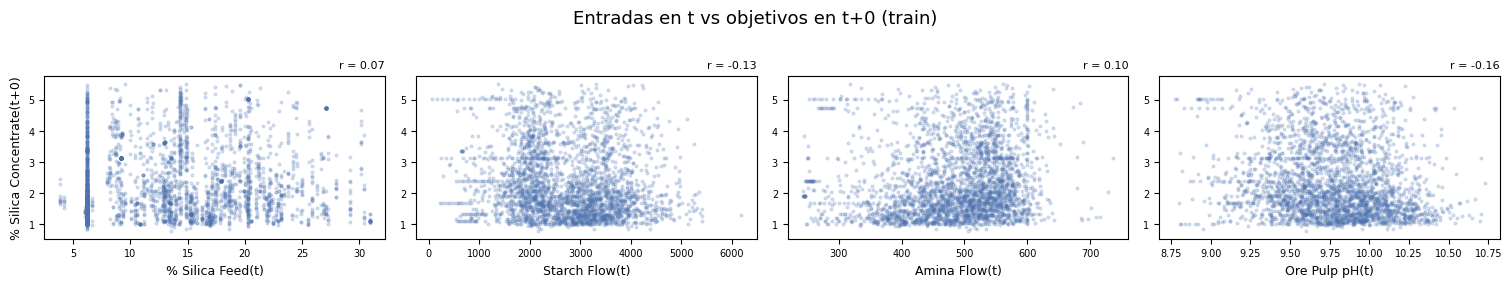

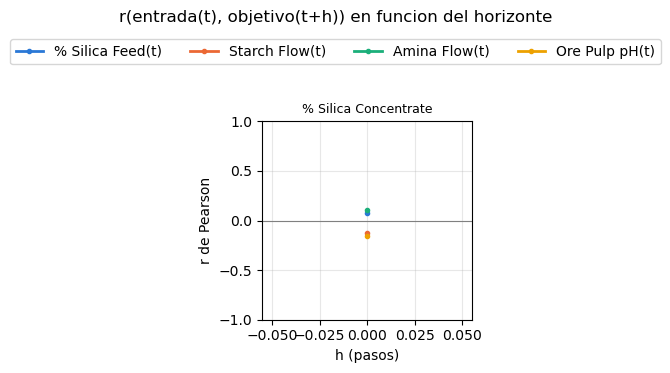

,h,0
entrada,objetivo,
% Silica Feed(t),% Silica Concentrate,0.07
Starch Flow(t),% Silica Concentrate,-0.13
Amina Flow(t),% Silica Concentrate,0.10
Ore Pulp pH(t),% Silica Concentrate,-0.16


In [115]:
# Dispersion de cada entrada en t frente a cada objetivo en t+SCATTER_HORIZON
# (tramo de train): una fila por objetivo, una columna por entrada. El r de cada
# panel es la relacion lineal que veria un modelo a ese horizonte.
in_names = [f'{short(c)}(t)' for c in scatter_input_cols]
out_names = [f'{short(t)}(t+{SCATTER_HORIZON})' for t in target_cols]
fc = scatter_matrix_data                                            # r con todas las filas
fc_plot = thin(scatter_matrix_data, scatter_matrix_data, SCATTER_MAX_POINTS)[0]   # puntos dibujados

fig, axes = plt.subplots(len(out_names), len(in_names),
                         figsize=(3.8 * len(in_names), 2.8 * len(out_names)), squeeze=False)
for i, y_name in enumerate(out_names):
    for j, x_name in enumerate(in_names):
        ax = axes[i, j]
        ax.scatter(fc_plot[x_name], fc_plot[y_name], s=4, alpha=0.2, color='#4C72B0')
        ax.set_title(f'r = {fc[x_name].corr(fc[y_name]):.2f}', fontsize=8, loc='right')
        ax.tick_params(labelsize=7)
        if i == len(out_names) - 1:
            ax.set_xlabel(x_name, fontsize=9)
        if j == 0:
            ax.set_ylabel(y_name, fontsize=9)
fig.suptitle(f'Entradas en t vs objetivos en t+{SCATTER_HORIZON} (train)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

# Como cae la relacion con el horizonte: r de cada entrada(t) con cada objetivo(t+h)
horizons = range(0, SCATTER_HORIZON + 1)
r_by_h = pd.DataFrame({
    h: forecast_frame(df_fs, scatter_input_cols, target_cols, h).corr()
         .loc[in_names, [f'{short(t)}(t+{h})' for t in target_cols]]
         .set_axis([short(t) for t in target_cols], axis=1).stack()
    for h in horizons
})
r_by_h.index.names = ['entrada', 'objetivo']
r_by_h.columns.name = 'h'

input_colors = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
fig, axes = plt.subplots(1, len(target_cols), figsize=(3.2 * len(target_cols), 3.2), sharey=True,
                         squeeze=False)
axes = axes[0]
for ax, t in zip(axes, [short(t) for t in target_cols]):
    for x_name, color in zip(in_names, input_colors):
        ax.plot(list(horizons), r_by_h.loc[(x_name, t)], marker='o', ms=3, lw=2,
                color=color, label=x_name)
    ax.axhline(0, color='grey', lw=0.8)
    ax.set_title(t, fontsize=9)
    ax.set_xlabel('h (pasos)')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('r de Pearson')
axes[0].set_ylim(-1, 1)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(labels), bbox_to_anchor=(0.5, 1.08))
fig.suptitle('r(entrada(t), objetivo(t+h)) en funcion del horizonte', y=1.15)
plt.tight_layout()
plt.show()

r_by_h.round(2)

> **No aplicable a este dataset.** Esta sección analizaba los tramos estáticos de
> `% Silica Feed` (análisis de laboratorio del dataset de flotación). Sus celdas de
> código se han convertido a texto (*raw*) para conservarlas sin que se ejecuten.

# Feature selection: efecto de los tramos estáticos de % Silica Feed

`% Silica Feed` es un input de laboratorio (ver sección *Missing data handle*) que se
mantiene en tramos ESTÁTICOS (mismo valor exacto) durante >= 1 día seguido
(`static_runs['% Silica Feed']`, calculado más arriba). Esto es un probable artefacto de
muestreo (el laboratorio no analiza con la frecuencia horaria del timestamp) y no una
dinámica real del proceso: durante esos tramos, `% Silica Feed` aparenta ser constante
frente al resto de variables que sí varían hora a hora, lo cual puede distorsionar las
métricas de selección de características (correlación, mutual information, wrappers)
tanto para `% Silica Feed` como para el resto de features que se comparan contra el
mismo target.

Se repite el pipeline de *filter methods* y *wrapper methods* (mismo `vs_feature_cols`,
`vs_target_col`, `n_select`) excluyendo las horas que caen dentro de un tramo estático
de `% Silica Feed`, y se compara con los resultados obtenidos con el dataset completo.

## Filter methods (sin tramos estáticos)

## Wrapper methods (sin tramos estáticos)

> **No aplicable a este dataset.** Esta sección analizaba el desbalance entre las
> columnas de flotación 04 y 05. Sus celdas de código se han convertido a texto
> (*raw*) para conservarlas sin que se ejecuten.

# Señal residuo: Flotation Column 04 vs 05

Las columnas de flotación 04 y 05 operan en paralelo (mismo grupo, ver
`sensor_groups` en *Outliers por grupo correlacionado*), así que se espera que
`Air Flow` y `Level` se muevan juntas entre ambas. La diferencia (residuo) entre
cada par captura el desbalance entre las dos columnas; se analiza qué otras
variables se correlacionan con ese desbalance (¿hay algo que lo explique, o es
ruido?).

## Correlación con lags: residuo(t) vs targets(t + lag)

La correlación instantánea puede no capturar el efecto si el desbalance entre
columnas 04/05 tarda en propagarse hasta el resultado final (tiempo de
residencia del mineral en el circuito de flotación). Se desplaza el residuo
hacia atrás `lag` horas (equivalente a comparar `residuo[t]` con
`target[t + lag]`) para `lag` de 0 a 6 horas, y se mide Pearson en cada paso.

Rango corto (0-6h): suficiente para un efecto de tránsito a corto plazo sin
diluir la muestra con demasiados `NaN` al final de la serie.

# Outlier handling

# Univariate methods

In [116]:
# Deteccion de outliers univariante por MAD, columna a columna
# Mismo criterio que el Hampel filter de mas abajo (mediana + MAD*1.4826) pero
# GLOBAL (no en ventana movil) y sobre df (horario), no df_raw (20s): aqui
# interesa relacionar el outlier con el target, que solo existe a resolucion
# horaria.
#
# modified z-score = (x - mediana) / (MAD * 1.4826)
# threshold=3.5 es el valor estandar propuesto por Iglewicz & Hoaglin (1993)
from scipy.stats import median_abs_deviation

mad_outlier_threshold = 3.5

mad_outlier_data = df[sensor_cols].dropna()

mad_median = mad_outlier_data.median()
mad_scaled = median_abs_deviation(mad_outlier_data, scale='normal')

modified_z = (mad_outlier_data - mad_median) / mad_scaled

mad_outlier_per_col = modified_z.abs() > mad_outlier_threshold

mad_outlier_summary = pd.DataFrame({
    'median': mad_median,
    'mad_scaled': mad_scaled,
    'n_outliers': mad_outlier_per_col.sum(),
    'pct_outliers': (mad_outlier_per_col.mean() * 100).round(2),
}).sort_values('n_outliers', ascending=False)
print(mad_outlier_summary)

# CRITERIO: marcar una fila como outlier solo si AL MENOS min_cols_agree
# sensores la senalan a la vez, no con que baste 1 (any(axis=1)). Con 19
# columnas, exigir 1 sola coincidencia deja que una unica señal con poca
# dispersion (ej. las Air Flow, con mad_scaled ~0.1-1.5 frente a medianas
# ~300: casi constantes, asi que pequeñas variaciones normales ya disparan
# el z-score) contamine el 68% de las filas por si sola. Exigir varias
# columnas de acuerdo simultaneo es mucho mas selectivo y evita ese sesgo.
min_cols_agree = 2
mad_row_is_outlier = mad_outlier_per_col.sum(axis=1) >= min_cols_agree

print(f'\nFilas marcadas como outlier (>= {min_cols_agree} sensores fuera de umbral a la vez): '
      f'{mad_row_is_outlier.sum()} de {len(mad_row_is_outlier)} '
      f'({mad_row_is_outlier.mean()*100:.2f}%)')
print(f'(para comparar, con el criterio "any" -1 sensor basta- salian '
      f'{mad_outlier_per_col.any(axis=1).sum()} filas, '
      f'{mad_outlier_per_col.any(axis=1).mean()*100:.2f}%)')

                           median   mad_scaled  n_outliers  pct_outliers
Ore Pulp Flow          399.842656     1.268959        1132         27.63
Ore Pulp Density         1.695705     0.048424         157          3.83
% Silica Concentrate     2.000000     0.978517          16          0.39
% Iron Feed             56.080000     5.144630           0          0.00
% Silica Feed           13.850000     7.798488           0          0.00
Starch Flow           2908.340847  1012.019543           0          0.00
Amina Flow             502.454283    80.684877           0          0.00
Ore Pulp pH              9.795850     0.363516           0          0.00
% Iron Concentrate      65.210000     1.082300           0          0.00

Filas marcadas como outlier (>= 2 sensores fuera de umbral a la vez): 75 de 4097 (1.83%)
(para comparar, con el criterio "any" -1 sensor basta- salian 1230 filas, 30.02%)


Filas con target valido: 4097, de las cuales outlier MAD: 75 (1.83%)


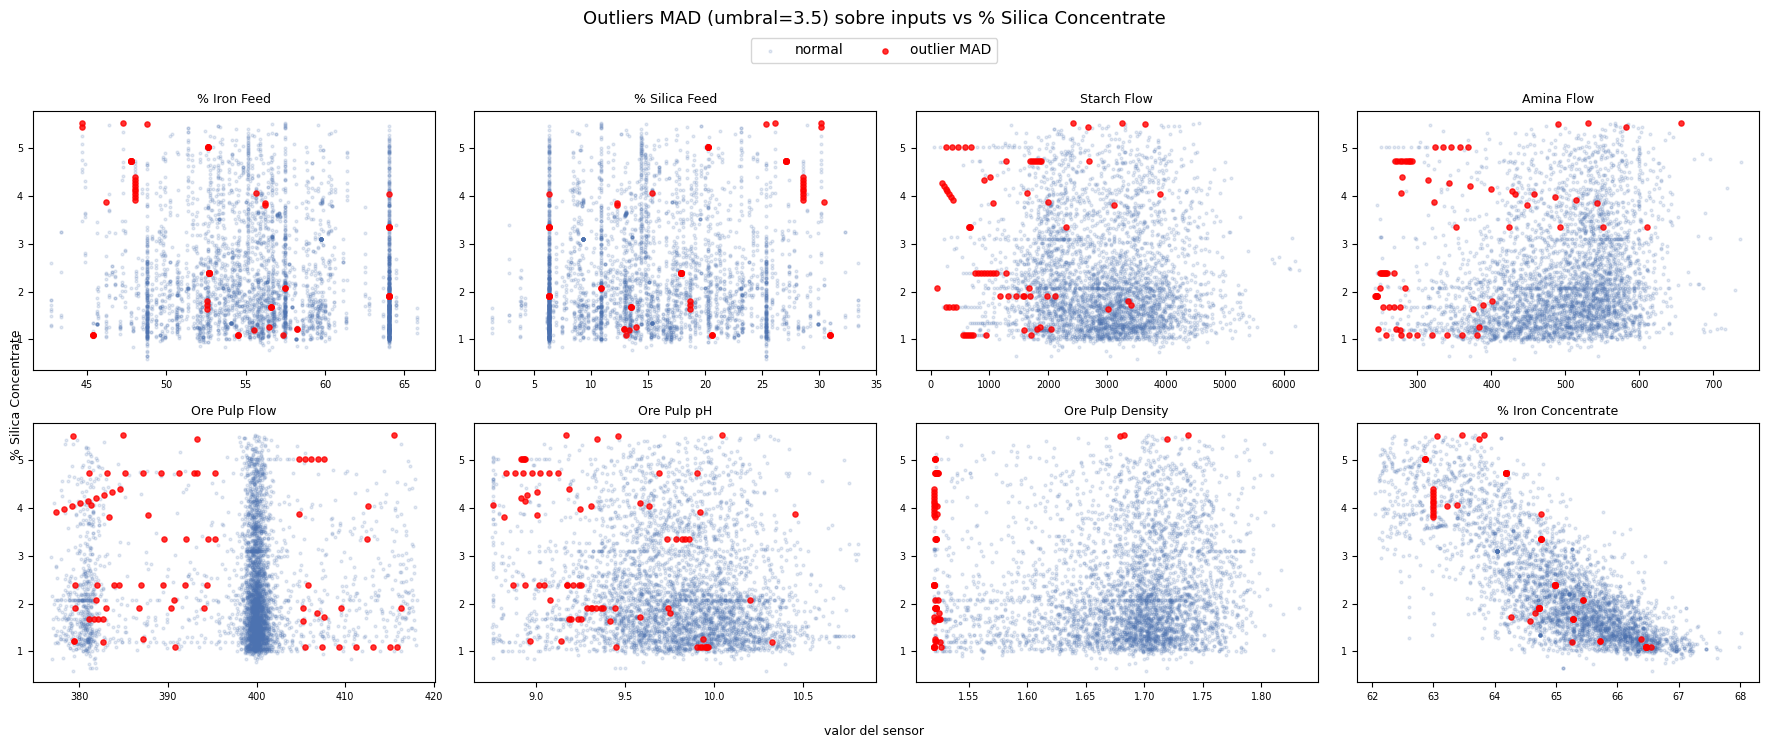

In [117]:
# Visualizacion: outliers MAD (por sensor) pintados sobre el scatter de cada
# sensor vs cada target, para juzgar "a ojo" si tienen sentido (ej. si caen en
# zonas de operacion anomala o parecen ruido de sensor puro).
#
# Objetivos: los de la seccion de seleccion de variables (target_cols). En cada
# figura se dibujan todas las sensor_cols salvo el propio objetivo.
mad_targets = target_cols

# dict.fromkeys: los objetivos ya estan en sensor_cols, sin el se duplicarian columnas
mad_plot_data = df[list(dict.fromkeys(sensor_cols + mad_targets))].dropna(subset=mad_targets)
mad_plot_outlier = mad_row_is_outlier.reindex(mad_plot_data.index, fill_value=False)

print(f'Filas con target valido: {len(mad_plot_data)}, '
      f'de las cuales outlier MAD: {mad_plot_outlier.sum()} '
      f'({mad_plot_outlier.mean()*100:.2f}%)')

n_cols = 4

for target in mad_targets:
    mad_inputs = [c for c in sensor_cols if c != target]
    n_rows = int(np.ceil(len(mad_inputs) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.5 * n_rows))
    axes = axes.flatten()

    for ax, signal in zip(axes, mad_inputs):
        ax.scatter(mad_plot_data.loc[~mad_plot_outlier, signal],
                   mad_plot_data.loc[~mad_plot_outlier, target],
                   s=4, alpha=0.15, color='#4C72B0', label='normal')
        ax.scatter(mad_plot_data.loc[mad_plot_outlier, signal],
                   mad_plot_data.loc[mad_plot_outlier, target],
                   s=14, alpha=0.8, color='red', label='outlier MAD', zorder=5)
        ax.set_title(short(signal), fontsize=9)
        ax.tick_params(labelsize=7)

    for ax in axes[len(mad_inputs):]:
        ax.axis('off')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02), fontsize=10)
    fig.suptitle(f'Outliers MAD (umbral={mad_outlier_threshold}) sobre inputs vs {short(target)}', y=1.05, fontsize=13)
    fig.supxlabel('valor del sensor', fontsize=9)
    fig.supylabel(short(target), fontsize=9)
    plt.tight_layout()
    plt.show()

In [118]:
# Hampel filter: outlier detection and replacement
# Version robusta de una media/desviacion movil: en vez de media+std (sensibles a
# outliers), usa mediana+MAD en una ventana centrada. Un punto es outlier si se
# aleja de la mediana local mas de n_sigmas * MAD_escalado (factor 1.4826, igual
# que en el MAD scaling de la seccion "Normalization" mas abajo).
# Opera sobre df_raw (crudo, 20s): es donde viven los outliers puntuales de alta
# frecuencia, igual que el resto de "Noise filtering".

def hampel_filter(series, window_size=15, n_sigmas=3):
    """Devuelve (serie_filtrada, mascara_outliers) via Hampel identifier."""
    k = 1.4826  # factor de consistencia MAD -> sigma bajo normalidad
    rolling_median = series.rolling(window_size, center=True, min_periods=1).median()
    mad = (series - rolling_median).abs().rolling(window_size, center=True, min_periods=1).median()
    threshold = n_sigmas * k * mad

    diff = (series - rolling_median).abs()
    is_outlier = diff > threshold

    filtered = series.copy()
    filtered[is_outlier] = rolling_median[is_outlier]
    return filtered, is_outlier


hampel_window = 15
hampel_n_sigmas = 3

df_hampel_outliers = pd.DataFrame(index=df_raw.index)
for signal in sensor_cols:
    filtered, is_outlier = hampel_filter(df_raw[signal], window_size=hampel_window, n_sigmas=hampel_n_sigmas)
    df_raw[signal + '_hampel'] = filtered
    df_hampel_outliers[signal] = is_outlier

hampel_summary = pd.DataFrame({
    'n_outliers': df_hampel_outliers.sum(),
    'pct_outliers': (df_hampel_outliers.mean() * 100).round(3),
}).sort_values('n_outliers', ascending=False)

hampel_summary

,n_outliers,pct_outliers
Starch Flow,82695,11.214
Ore Pulp Density,58487,7.931
Ore Pulp pH,53220,7.217
Amina Flow,34322,4.654
Ore Pulp Flow,20781,2.818
% Iron Feed,0,0.000
% Silica Feed,0,0.000
% Iron Concentrate,0,0.000
% Silica Concentrate,0,0.000


In [119]:
# # Visualizacion: mismas secciones random que en "Noise filtering", marcando
# # los puntos identificados como outliers por Hampel
# for signal in sensor_cols:
#     fig, axes = plt.subplots(n_sections, 1, figsize=(12, 4 * n_sections))
#     if n_sections == 1:
#         axes = [axes]

#     for ax, start in zip(axes, section_starts):
#         end = start + section_duration
#         mask = (df_raw.index >= start) & (df_raw.index < end)
#         outlier_mask = mask & df_hampel_outliers[signal].reindex(df_raw.index, fill_value=False)

#         ax.plot(df_raw.index[mask], df_raw[signal][mask],
#                 label='Original', alpha=0.4, linewidth=1)
#         ax.plot(df_raw.index[mask], df_raw[signal + '_hampel'][mask],
#                 label=f'Hampel filtrado (w={hampel_window}, n_sigmas={hampel_n_sigmas})', linewidth=1.5)
#         ax.scatter(df_raw.index[outlier_mask], df_raw[signal][outlier_mask],
#                    color='red', s=25, zorder=5, label='Outlier detectado')

#         ax.set_title(f'{signal} | {start.strftime("%Y-%m-%d %H:%M")} → {end.strftime("%Y-%m-%d %H:%M")}')
#         ax.legend(loc='upper right', fontsize=8)
#         ax.grid(alpha=0.3)

#     plt.tight_layout()
#     plt.show()

# Multivariate methods

In [120]:
# FAST-MCD algorithm

# compute MCD-based Mahalanobis distances
from sklearn.covariance import MinCovDet
# Datos comunes a los 4 metodos multivariantes (FAST-MCD, KDE, GMM, LOF): sin NaN
# y submuestreados de forma regular. A 1 min (~130k filas) KDE evalua cada punto
# contra todos (~n^2, horas) y LOF/GMM tardan bastante; con la misma submuestra
# en los cuatro la comparacion final sigue siendo punto a punto.
MV_MAX_ROWS = 15_000
mv_data = thin(df[sensor_cols].dropna(), df[sensor_cols].dropna(), MV_MAX_ROWS)[0]
print(f'Datos multivariantes: {len(mv_data):,} filas (de {len(df):,})')

MCD_cov = MinCovDet(random_state=42).fit(mv_data)
MD_MCD = pd.Series(MCD_cov.mahalanobis(mv_data), index=mv_data.index)


Datos multivariantes: 4,097 filas (de 4,415)


# Outliers por grupo correlacionado (KNN)

In [121]:
# Deteccion de outliers dentro de grupos de sensores fisicamente correlacionados
# (se espera que se muevan juntas). En vez
# de MAD/z-score global (asume una unica relacion fija -> falla con cambios de
# regimen, ver seccion "Univariate methods" mas arriba) se usa KNN: un punto
# es outlier si esta lejos de sus k vecinos mas cercanos DENTRO DEL SUBESPACIO
# de ese grupo. Como los vecinos se buscan en todo el historico (no una formula
# fija), esto captura relaciones no lineales entre sensores del grupo y no
# penaliza que el grupo entero cambie de regimen (esos puntos tendran muchos
# "vecinos" parecidos en otros momentos del mismo regimen).
#
# Grupos: bloques de senales muy correladas entre si segun la seccion
# "Colinealidad entre entradas" (|r| >= 0.75 en train).
from scipy.stats import median_abs_deviation
from sklearn.neighbors import NearestNeighbors

sensor_group_signals = {
    'alimentacion (laboratorio)': ['% Iron Feed', '% Silica Feed'],                 # fuertemente anticorreladas
    'pulpa': ['Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density'],
    'reactivos': ['Starch Flow', 'Amina Flow'],
}
full_name = {short(c): c for c in sensor_cols}
sensor_groups = {g: [full_name[s] for s in sigs] for g, sigs in sensor_group_signals.items()}

knn_k = 20  # mismo orden que LOF (n_neighbors=20) para comparar
knn_group_outlier = {}
knn_group_summary_rows = []

for group_name, group_cols in sensor_groups.items():
    group_data = df[group_cols].dropna()

    # MAD scaling (no StandardScaler): dentro de un grupo, un sensor puede
    # tener mucha menos dispersion que otro (ver mad_scaling_summary), y con
    # StandardScaler el ruido de baja escala pesaria igual que la señal real
    group_median = group_data.median()
    group_mad = median_abs_deviation(group_data, scale='normal')
    group_scaled = (group_data - group_median) / group_mad

    nn = NearestNeighbors(n_neighbors=knn_k + 1).fit(group_scaled)  # +1: incluye el propio punto
    distances, _ = nn.kneighbors(group_scaled)
    mean_knn_dist = distances[:, 1:].mean(axis=1)  # excluye distancia a si mismo (columna 0)

    # umbral: mismo criterio percentil 95 usado en FAST-MCD/KDE/GMM mas arriba
    dist_threshold = np.percentile(mean_knn_dist, 95)
    is_outlier = pd.Series(mean_knn_dist > dist_threshold, index=group_data.index)

    knn_group_outlier[group_name] = is_outlier
    knn_group_summary_rows.append({
        'group': group_name,
        'n_outliers': is_outlier.sum(),
        'pct_outliers': round(is_outlier.mean() * 100, 2),
    })

knn_group_summary = pd.DataFrame(knn_group_summary_rows).set_index('group')
knn_group_summary

,n_outliers,pct_outliers
group,,
alimentacion (laboratorio),204,4.98
pulpa,205,5.00
reactivos,205,5.00


# Outliers univariantes (KNN)

KNN aplicado a **cada variable por separado** (1 dimensión), sin las columnas de flotación. Un punto es outlier si su distancia media a sus k vecinos más cercanos (en valor, no en tiempo) es anómalamente grande, es decir, si cae en una zona donde casi no hay otros valores.

- A diferencia de MAD/z-score, no mide distancia al centro: un valor extremo pero frecuente (p. ej. un régimen de operación distinto) **no** se marca; un valor aislado **sí**.
- **Umbral**: modified z-score > 3.5 sobre el **log** de la distancia KNN. Sin el log, la distancia está tan sesgada (la mayoría casi 0, pocas grandes) que la MAD sale diminuta y se marcaba hasta un 28 % de los puntos.
- **Rachas repetidas**: las variables de laboratorio mantienen el mismo valor durante horas o días. Esas repeticiones se colapsan a un único punto antes del KNN (cada medición cuenta una vez); si no, un valor mantenido 100 h tiene 20 vecinos a distancia 0 y los valores que duran poco parecen aislados artificialmente. El resultado se propaga a todas las horas de la racha.


In [122]:
# KNN univariante: una deteccion por variable
from sklearn.neighbors import NearestNeighbors
from scipy.stats import median_abs_deviation

knn_uni_cols = sensor_cols + lab_cols
knn_uni_k = 20                # mismo k que el KNN por grupos
knn_uni_z_threshold = 3.5     # modified z-score sobre log(distancia KNN)

knn_uni_outlier = {}
knn_uni_skipped = []
knn_uni_rows = []
for col in knn_uni_cols:
    s = df[col].dropna()

    # colapsar rachas de valores identicos consecutivos -> un punto por medicion
    run_id = (s != s.shift()).cumsum()
    runs = s.groupby(run_id).first()
    x = runs.to_numpy().reshape(-1, 1)   # 1D: no hace falta escalar
    if len(runs) <= knn_uni_k:
        # senal discreta/etiqueta (p.ej. fault_type a 1 min): menos tramos que vecinos
        knn_uni_skipped.append(col)
        continue

    nn = NearestNeighbors(n_neighbors=knn_uni_k + 1).fit(x)  # +1: incluye el propio punto
    distances, _ = nn.kneighbors(x)
    log_dist = np.log(distances[:, 1:].mean(axis=1) + 1e-12)

    z = (log_dist - np.median(log_dist)) / median_abs_deviation(log_dist, scale='normal')
    run_is_out = pd.Series(z > knn_uni_z_threshold, index=runs.index)

    # propagar a todas las horas de cada racha
    is_out = pd.Series(run_is_out.reindex(run_id).to_numpy(), index=s.index)

    knn_uni_outlier[col] = is_out
    knn_uni_rows.append({
        'variable': col,
        'n_horas': len(s),
        'n_mediciones_distintas': len(runs),
        'n_outliers_horas': int(is_out.sum()),
        'pct_outliers': round(is_out.mean() * 100, 2),
    })

knn_uni_cols = [c for c in knn_uni_cols if c not in knn_uni_skipped]   # las que se dibujan abajo
print(f'Sin deteccion (<= {knn_uni_k} tramos distintos):', knn_uni_skipped or 'ninguna')
knn_uni_summary = pd.DataFrame(knn_uni_rows).set_index('variable')
knn_uni_summary


Sin deteccion (<= 20 tramos distintos): ninguna


,n_horas,n_mediciones_distintas,n_outliers_horas,pct_outliers
variable,,,,
% Iron Feed,4097,307,906,22.11
% Silica Feed,4097,307,75,1.83
Starch Flow,4097,4095,311,7.59
Amina Flow,4097,4095,266,6.49
Ore Pulp Flow,4097,4095,7,0.17
Ore Pulp pH,4097,4086,231,5.64
Ore Pulp Density,4097,4094,17,0.41
% Iron Concentrate,4097,3644,23,0.56
% Silica Concentrate,4097,3651,0,0.00


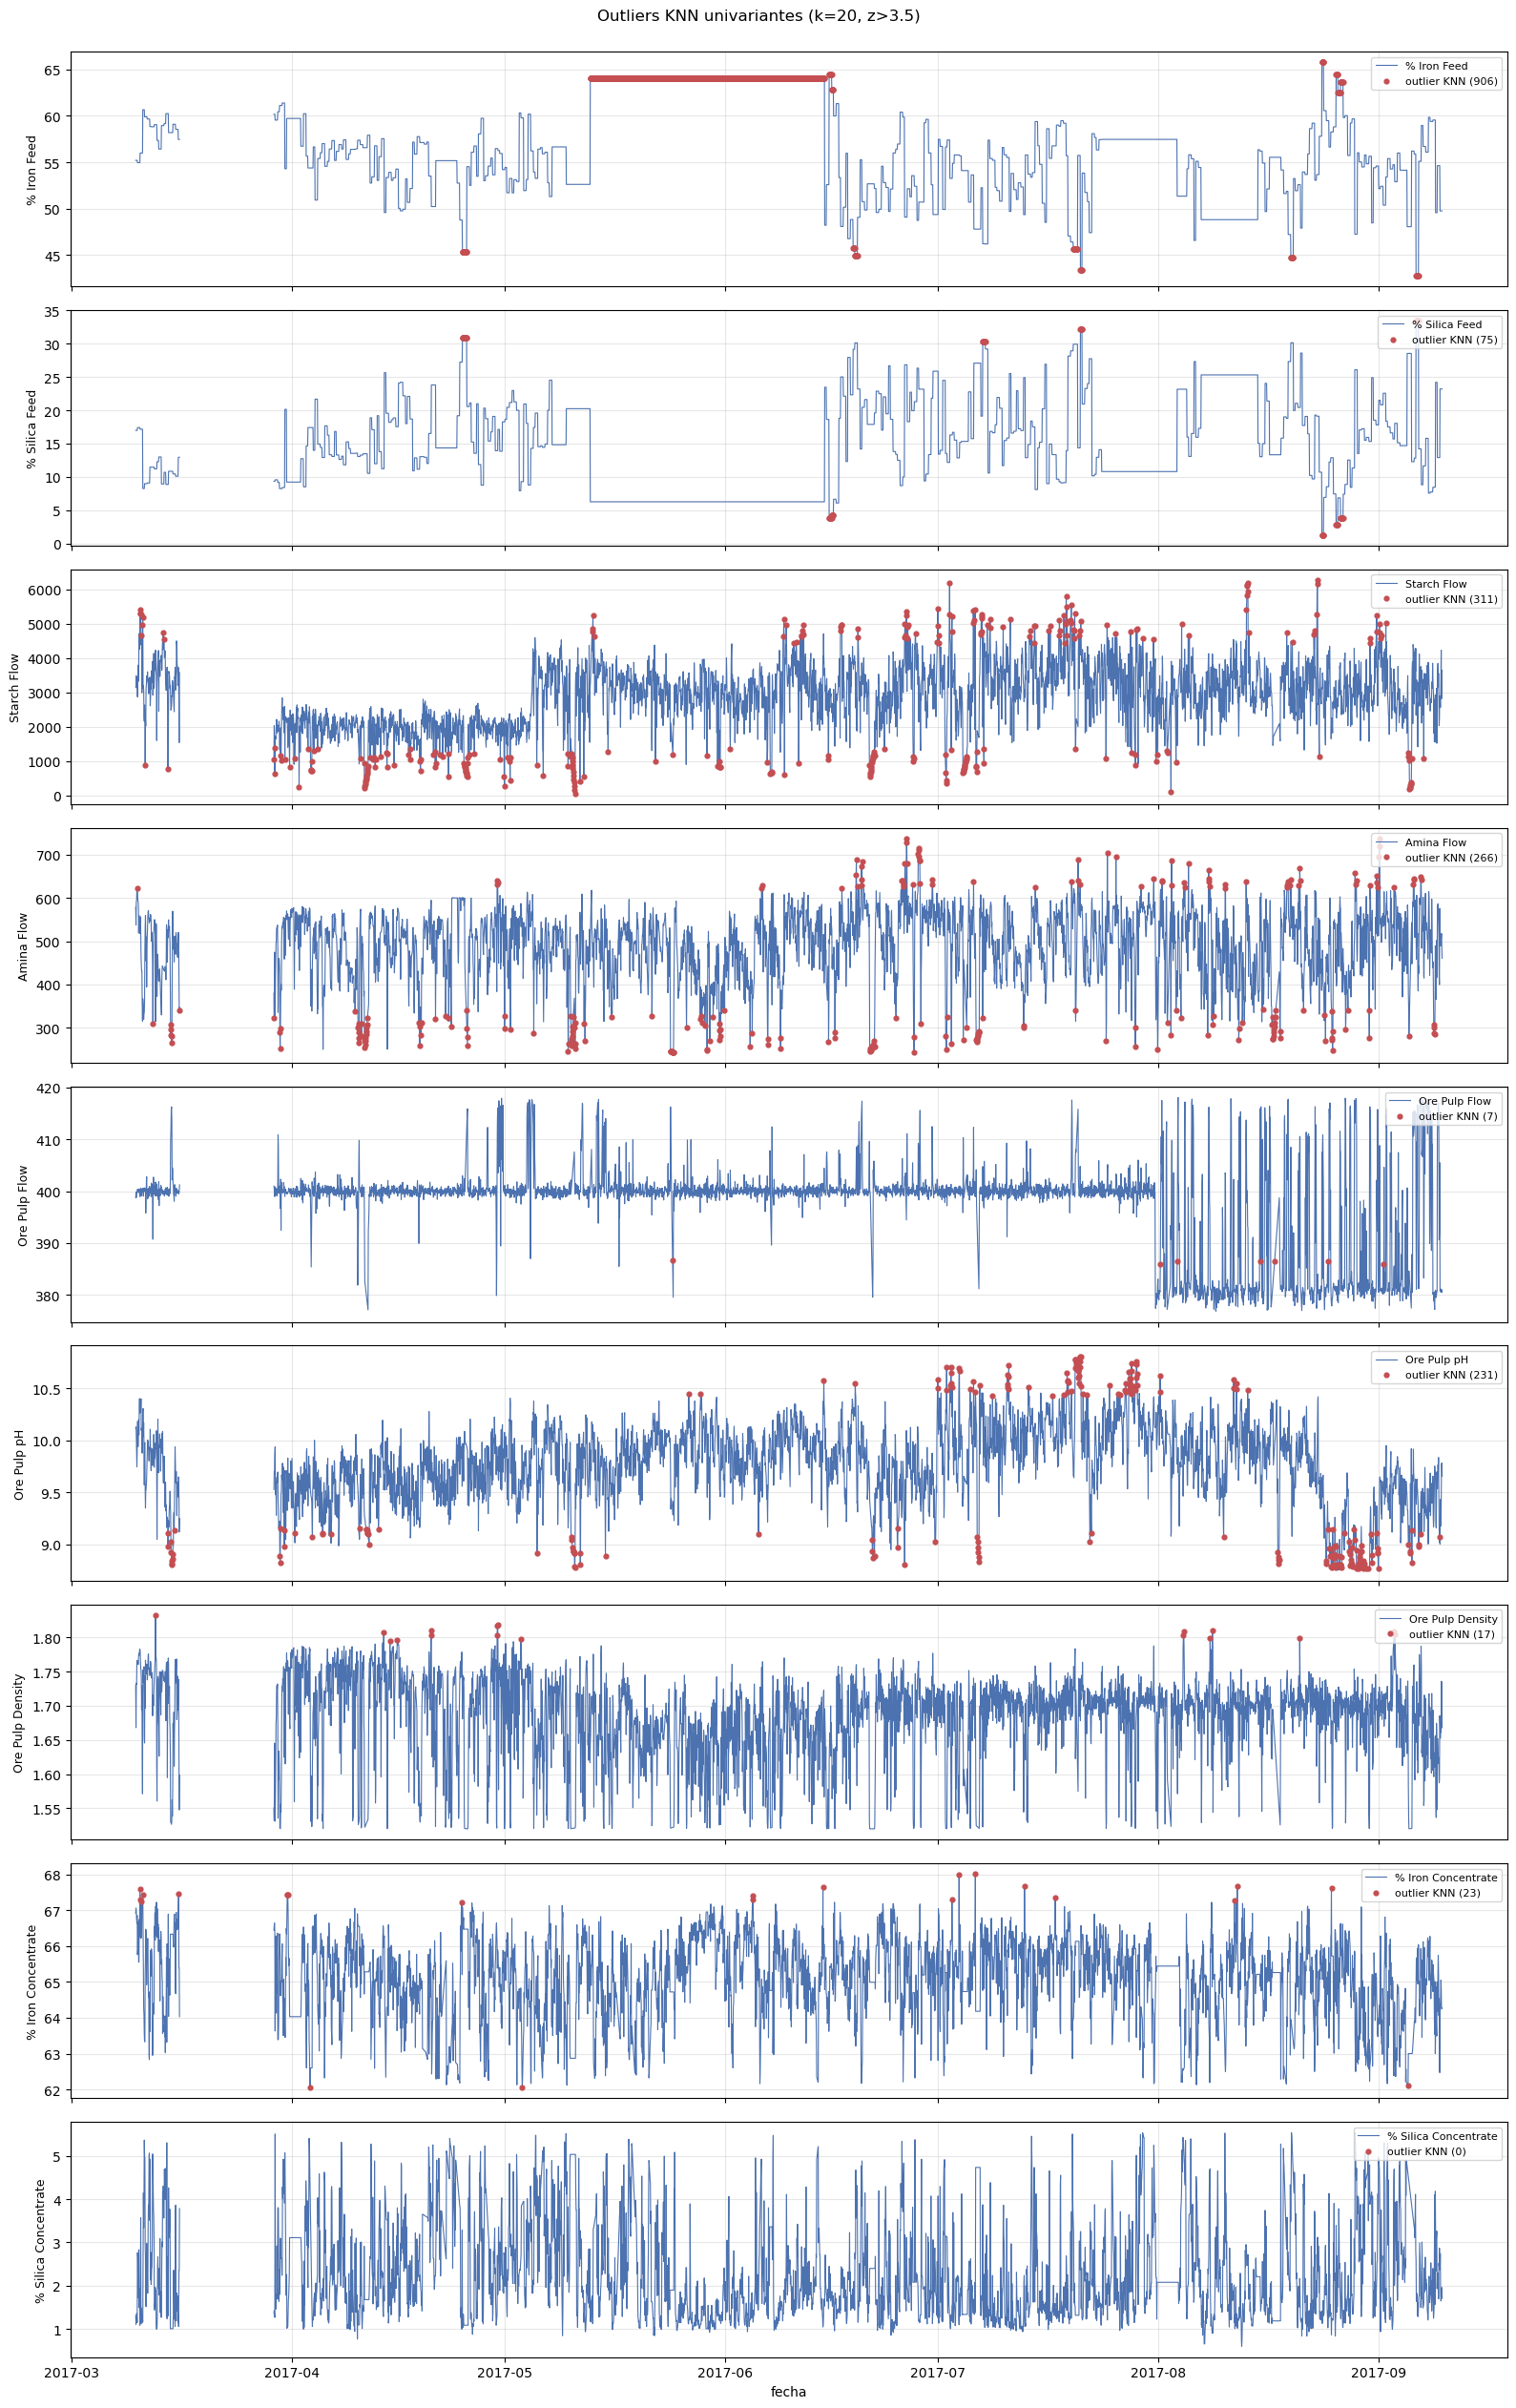

In [123]:
# Serie temporal completa de cada variable con los outliers KNN univariantes en rojo
fig, axes = plt.subplots(len(knn_uni_cols), 1, figsize=(16, 2.8 * len(knn_uni_cols)), sharex=True)

for ax, col in zip(axes, knn_uni_cols):
    s = df[col]
    out_idx = knn_uni_outlier[col][knn_uni_outlier[col]].index
    ax.plot(s.index, s.values, color='#4C72B0', linewidth=0.8, label=col)
    ax.scatter(out_idx, s.loc[out_idx], color='#C44E52', s=12, zorder=3,
               label=f'outlier KNN ({len(out_idx)})')
    ax.set_ylabel(col, fontsize=9)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('fecha')
fig.suptitle(f'Outliers KNN univariantes (k={knn_uni_k}, z>{knn_uni_z_threshold})', y=1.0)
plt.tight_layout()
plt.show()


# Data mining methods

# Density based

In [124]:
# KDE (Kernel Density Estimation): estima la densidad de probabilidad multivariante
# de los datos. Los puntos en regiones de baja densidad (poco frecuentes dado el
# resto de variables) se marcan como outliers. A diferencia de FAST-MCD (asume
# una elipse/gaussiana), KDE no asume ninguna forma concreta de la distribucion.
#
# bandwidth: controla el suavizado del kernel. Se usa Scott's rule (default de
# sklearn es distinto, GridSearch seria mas riguroso pero mas caro aqui).
from sklearn.neighbors import KernelDensity

kde_data = mv_data   # submuestra comun (ver FAST-MCD)

# Escalado previo obligatorio: KDE usa distancias euclidianas entre puntos, y
# las columnas tienen escalas muy distintas (ver mad_scaling_summary mas abajo,
# ej. Starch Flow ~2880 vs Ore Pulp Density ~1.7). Sin escalar, las variables
# de mayor magnitud dominarian la densidad.
from sklearn.preprocessing import StandardScaler

kde_scaler = StandardScaler()
kde_data_scaled = kde_scaler.fit_transform(kde_data)

kde_model = KernelDensity(kernel='gaussian', bandwidth='scott').fit(kde_data_scaled)
log_density = kde_model.score_samples(kde_data_scaled)

# umbral: percentil 5 mas bajo de densidad -> outlier (mismo criterio que
# "cola de la distribucion de densidades", ajustable segun cuantos outliers
# se esperen)
kde_threshold = np.percentile(log_density, 5)
kde_is_outlier = pd.Series(log_density < kde_threshold, index=kde_data.index)

print(f'KDE outliers: {kde_is_outlier.sum()} de {len(kde_is_outlier)} ({kde_is_outlier.mean()*100:.2f}%)')

KDE outliers: 205 de 4097 (5.00%)


# Clustering based

In [125]:
# GMM (Gaussian Mixture Model): ajusta k gaussianas a los datos (util si hay
# distintos regimenes de operacion, cada uno con su propia "nube" de valores
# normales). Un punto se marca outlier si su log-verosimilitud bajo la mezcla
# ajustada es muy baja (no encaja bien en ninguno de los clusters).
#
# A diferencia de KDE (no parametrico, una sola densidad global), GMM asume
# que los datos vienen de una mezcla de k gaussianas -> mas apropiado si se
# sospecha de multimodalidad (ej. planta parada vs en marcha).
from sklearn.mixture import GaussianMixture

gmm_data = mv_data   # submuestra comun (ver FAST-MCD)

gmm_scaler = StandardScaler()
gmm_data_scaled = gmm_scaler.fit_transform(gmm_data)

# Seleccion de k por BIC (penaliza complejidad, evita sobreajustar el numero
# de clusters)
bic_scores = []
k_range = range(1, 8)
for k in k_range:
    gmm_k = GaussianMixture(n_components=k, random_state=42).fit(gmm_data_scaled)
    bic_scores.append(gmm_k.bic(gmm_data_scaled))

best_k = k_range[int(np.argmin(bic_scores))]
print(f'Numero de componentes seleccionado por BIC: {best_k}')

gmm_model = GaussianMixture(n_components=best_k, random_state=42).fit(gmm_data_scaled)
gmm_log_likelihood = gmm_model.score_samples(gmm_data_scaled)

gmm_threshold = np.percentile(gmm_log_likelihood, 5)
gmm_is_outlier = pd.Series(gmm_log_likelihood < gmm_threshold, index=gmm_data.index)

print(f'GMM outliers: {gmm_is_outlier.sum()} de {len(gmm_is_outlier)} ({gmm_is_outlier.mean()*100:.2f}%)')

Numero de componentes seleccionado por BIC: 7
GMM outliers: 205 de 4097 (5.00%)


# Neighbor based

In [126]:
# LOF (Local Outlier Factor): compara la densidad local de cada punto con la
# densidad local de sus k vecinos mas cercanos. Un punto es outlier si su
# densidad es notablemente menor que la de su vecindario (outlier LOCAL, a
# diferencia de KDE/GMM que comparan contra la densidad GLOBAL).
# Util para detectar outliers en regiones que globalmente son densas pero
# donde el punto en cuestion sigue siendo anomalo respecto a sus vecinos
# inmediatos (ej. un cambio brusco de regimen que KDE/GMM no verian como raro
# porque cae dentro de una nube densa "en general").
from sklearn.neighbors import LocalOutlierFactor

lof_data = mv_data   # submuestra comun (ver FAST-MCD)

lof_scaler = StandardScaler()
lof_data_scaled = lof_scaler.fit_transform(lof_data)

# contamination='auto' deja que sklearn decida el umbral; n_neighbors=20 es el
# valor por defecto recomendado en el paper original de LOF (Breunig et al. 2000)
lof_model = LocalOutlierFactor(n_neighbors=20, contamination='auto')
lof_labels = lof_model.fit_predict(lof_data_scaled)  # -1 = outlier, 1 = inlier
lof_scores = -lof_model.negative_outlier_factor_  # mayor score = mas anomalo

lof_is_outlier = pd.Series(lof_labels == -1, index=lof_data.index)

print(f'LOF outliers: {lof_is_outlier.sum()} de {len(lof_is_outlier)} ({lof_is_outlier.mean()*100:.2f}%)')

LOF outliers: 35 de 4097 (0.85%)


In [127]:
# Comparacion de los metodos multivariantes de deteccion de outliers:
# FAST-MCD (elipse robusta) vs KDE (densidad global no parametrica) vs
# GMM (mezcla de gaussianas, capta multimodalidad) vs LOF (densidad local)
mcd_threshold = np.percentile(MD_MCD, 95)
mcd_is_outlier = MD_MCD > mcd_threshold

outlier_comparison = pd.DataFrame({
    'FAST_MCD': mcd_is_outlier,
    'KDE': kde_is_outlier,
    'GMM': gmm_is_outlier,
    'LOF': lof_is_outlier,
})
outlier_comparison['n_methods_agree'] = outlier_comparison.sum(axis=1)

agreement_summary = pd.DataFrame({
    'n_outliers': outlier_comparison[['FAST_MCD', 'KDE', 'GMM', 'LOF']].sum(),
    'pct_outliers': (outlier_comparison[['FAST_MCD', 'KDE', 'GMM', 'LOF']].mean() * 100).round(2),
})
print(agreement_summary)
print()
print('Puntos marcados como outlier por los 4 metodos a la vez:',
      (outlier_comparison['n_methods_agree'] == 4).sum())
print('Puntos marcados por al menos 3 de los 4 metodos:',
      (outlier_comparison['n_methods_agree'] >= 3).sum())

          n_outliers  pct_outliers
FAST_MCD         205          5.00
KDE              205          5.00
GMM              205          5.00
LOF               35          0.85

Puntos marcados como outlier por los 4 metodos a la vez: 2
Puntos marcados por al menos 3 de los 4 metodos: 18


# Normalization

In [128]:
# MAD scaling: alternativa robusta al z-score estandar
# z_MAD = (x - mediana) / (MAD * 1.4826)
# El factor 1.4826 hace que MAD sea un estimador consistente de sigma bajo
# normalidad (para que z_MAD sea comparable en escala a un z-score normal).
# Es mas robusto que StandardScaler porque mediana y MAD, a diferencia de
# media y desviacion estandar, no se distorsionan con outliers extremos.
from scipy.stats import median_abs_deviation

mad_data = df[sensor_cols].dropna()

median_ = mad_data.median()
mad_ = median_abs_deviation(mad_data, scale='normal')  # ya aplica el factor 1.4826

df_mad_scaled = (mad_data - median_) / mad_

mad_scaling_summary = pd.DataFrame({
    'median': median_,
    'mad_scaled': mad_,
}).sort_values('mad_scaled', ascending=False)

mad_scaling_summary


,median,mad_scaled
Starch Flow,2908.340847,1012.019543
Amina Flow,502.454283,80.684877
% Silica Feed,13.850000,7.798488
% Iron Feed,56.080000,5.144630
Ore Pulp Flow,399.842656,1.268959
% Iron Concentrate,65.210000,1.082300
% Silica Concentrate,2.000000,0.978517
Ore Pulp pH,9.795850,0.363516
Ore Pulp Density,1.695705,0.048424


# Exportar dataset para entrenamiento

Este notebook solo prepara los datos; el entrenamiento se hace en otros notebooks
que cargan el CSV exportado aquí.

Se exporta la serie **sin desplazar** (sin lags ni objetivo adelantado) a resolución
horaria, con el preproceso aplicado:

- Sin las columnas `Flotation Column ...` ni `% Iron Concentrate` (fuga de información).
- Sin las horas del hueco de 13 días del dataset original (filas sin ninguna lectura).
- **Corrección de skewness en las entradas**: para cada entrada se elige, **solo con train**,
  la transformación (Log, Raíz, Box-Cox, Yeo-Johnson) que deja el menor |skew|; se
  aplica a todas las entradas (`SKEW_THRESHOLD = 0`) salvo que ninguna mejore el skew de la original. Los parámetros (λ, desplazamiento,
  media/std) se ajustan con train y se reutilizan en val/test (sin fuga de información).
  Las variables con skew negativo se reflejan antes y se les devuelve el signo después,
  así que **conservan el sentido** de su relación con el objetivo.
- El objetivo `% Silica Concentrate` se exporta **sin transformar**.
- No se aplica: filtrado de ruido, eliminación de outliers ni escalado (se hace en el
  pipeline de entrenamiento, ajustado con train).

Salidas: `<datos>.csv` (con skewness corregido), `<datos>_noskew.csv` (mismas filas y split, sin corregir, para comparar el entrenamiento), (señales preprocesadas + columna `split` train/val/test cronológica)
y `<datos>_meta.json` (transformación y parámetros por variable, entradas elegidas, splits).

In [ ]:
# Exportar el dataset preprocesado (CSV) + metadatos para los notebooks de entrenamiento
import json
from pathlib import Path
from scipy.stats import skew, boxcox, yeojohnson

EXPORT_DIR = Path('../Datasets')
EXPORT_NAME = f'MiningProcess_Flotation_preprocessed_{RESAMPLE_RULE or "raw"}'
if any('Flotation Column' in c for c in sensor_cols):
    EXPORT_NAME += '_flotcols'   # variante con las columnas de flotacion
VAL_FRAC = 0.2           # despues de train (TRAIN_FRAC); el resto es test
SKEW_THRESHOLD = 0.0     # |skew| (train) por encima del cual se prueba a corregir (0 = todas las entradas)
SKEW_METHODS = ['Log', 'Sqrt', 'Box-Cox', 'Yeo-Johnson']

target_signals = [short(t) for t in target_cols]
input_signals = [c for c in sensor_cols if c not in target_cols and short(c) not in EXCLUDE_FROM_INPUTS]

# Se descartan las filas sin ninguna lectura (hueco de 13 dias tras el resample horario)
export_df = df[input_signals + target_cols].dropna(how='all').copy()
raw_df = export_df.copy()   # version sin transformar, para comparar en el entrenamiento
n_rows = len(export_df)
n_tr, n_va = int(n_rows * TRAIN_FRAC), int(n_rows * (TRAIN_FRAC + VAL_FRAC))
train_part = export_df.iloc[:n_tr]
print(f'Filas: {n_rows:,} (descartadas por hueco: {len(df) - n_rows:,}) | train {n_tr:,}')


def fit_skew(x_train):
    """Ajusta con train todas las transformaciones y devuelve la de menor |skew|.
    Devuelve (metodo, parametros, skew_original, skew_tras_transformar)."""
    x = x_train.dropna().to_numpy()
    s0 = skew(x)
    reflect = bool(s0 < 0)
    xp = -x if reflect else x
    shift = xp.min()
    pos = xp - shift + 1.0                               # >= 1 (log y Box-Cox exigen > 0)
    mu, sd = x.mean(), x.std()
    best = None
    for m in SKEW_METHODS:
        if m == 'Log':
            v, p = np.log(pos), {}
        elif m == 'Sqrt':
            v, p = np.sqrt(pos), {}
        elif m == 'Box-Cox':
            v, lam = boxcox(pos)
            p = {'lambda': float(lam)}
        else:  # Yeo-Johnson sobre la variable estandarizada (ver celda de skewness)
            v, lam = yeojohnson((x - mu) / sd)
            p = {'lambda': float(lam)}
        # el skew se mide con el signo ya devuelto (Yeo-Johnson no refleja)
        sk = skew(v) if m == 'Yeo-Johnson' else skew(-v if reflect else v)
        if best is None or abs(sk) < abs(best[3]):
            best = (m, dict(p, reflect=reflect, shift=float(shift), mean=float(mu), std=float(sd)), s0, sk)
    return best


def apply_skew(x, method, p):
    """Aplica la transformacion ya ajustada (parametros de train) a cualquier tramo."""
    x = x.astype(float)
    if method == 'Yeo-Johnson':
        out = yeojohnson(((x - p['mean']) / p['std']).to_numpy(), lmbda=p['lambda'])
        return pd.Series(out, index=x.index)
    xp = -x if p['reflect'] else x
    pos = (xp - p['shift'] + 1.0).clip(lower=1e-6)       # valores fuera del rango de train
    if method == 'Log':
        v = np.log(pos)
    elif method == 'Sqrt':
        v = np.sqrt(pos)
    else:
        v = pd.Series(boxcox(pos.to_numpy(), lmbda=p['lambda']), index=x.index)
    return -v if p['reflect'] else v                     # devuelve el sentido original


skew_report, skew_params = [], {}
for col in input_signals:
    method, params, s0, s1 = fit_skew(train_part[col])
    # se aplica la mejor transformacion salvo que no mejore el skew de la original
    corrected = abs(s0) > SKEW_THRESHOLD and abs(s1) < abs(s0)
    skew_report.append({'columna': col, 'skew_train': s0,
                        'metodo': method if corrected else 'ninguno',
                        'skew_train_tras': s1 if corrected else s0})
    if corrected:
        skew_params[col] = {'method': method, **params}
        export_df[col] = apply_skew(export_df[col], method, params)

skew_report = pd.DataFrame(skew_report).set_index('columna')
display(skew_report.round(3))
print(f'Corregidas: {len(skew_params)} de {len(input_signals)} entradas '
      f'| |skew| medio en train: {skew_report["skew_train"].abs().mean():.3f} -> '
      f'{skew_report["skew_train_tras"].abs().mean():.3f}')

# split cronologico (mismo para ambas versiones)
export_df['split'] = pd.Categorical(
    ['train'] * n_tr + ['val'] * (n_va - n_tr) + ['test'] * (n_rows - n_va),
    categories=['train', 'val', 'test'])
splits = {s: [str(export_df.index[export_df['split'] == s].min()),
              str(export_df.index[export_df['split'] == s].max())]
          for s in ['train', 'val', 'test']}

meta = {
    'source_csv': str(filepath),
    'target': target_signals,
    'input_cols': input_signals,
    'dropped_cols': dropped_cols + list(EXCLUDE_FROM_INPUTS),
    'dropped_constant_cols': {c: float(v) for c, v in constant_values.items()},
    'resample': {'rule': RESAMPLE_RULE, 'agg': RESAMPLE_AGG,
                 'timestamp_spread_s': TIMESTAMP_SPREAD_S if TIMESTAMP_SPREAD else None},
    'horizon': str(HORIZON_TIME),
    'skew': {'threshold': SKEW_THRESHOLD, 'fitted_on': 'train', 'transforms': skew_params,
             'untransformed': [c for c in input_signals if c not in skew_params]},
    'selection': {'n_select': n_select, 'min_votes': MIN_VOTES, 'collinear_r': COLLINEAR_R,
                  'input_cols_selected': {t: [feature_full[f] for f in feats]
                                          for t, feats in selected_inputs.items()},
                  'input_cols_shared': final_input_cols},
    'splits': splits,
    'not_applied': ['filtrado de ruido', 'eliminacion de outliers', 'escalado'],
    'columns': list(export_df.columns),
}

EXPORT_DIR.mkdir(parents=True, exist_ok=True)
data_path = EXPORT_DIR / f'{EXPORT_NAME}.csv'
meta_path = EXPORT_DIR / f'{EXPORT_NAME}_meta.json'
export_df.to_csv(data_path, index_label=TIMESTAMP_COL)
raw_path = EXPORT_DIR / f'{EXPORT_NAME}_noskew.csv'   # mismas filas y split, sin corregir skewness
raw_df.assign(split=export_df['split']).to_csv(raw_path, index_label=TIMESTAMP_COL)
meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding='utf-8')

print(f'Datos:      {data_path.resolve()}  ({export_df.shape[0]:,} filas x {export_df.shape[1]} columnas, '
      f'{data_path.stat().st_size / 1e6:.1f} MB)')
print(f'Sin skew:   {raw_path.resolve()}')
print(f'Metadatos:  {meta_path.resolve()}')
print(export_df['split'].value_counts().reindex(['train', 'val', 'test']).to_string())